In [1]:
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
import json

class HybridDataset(Dataset):
    def __init__(self, json_file, frame_rate=60, clip_duration=2, max_missing=5, shift_step=10):
        self.json_file = json_file
        self.num_frames = frame_rate * clip_duration  # 120 frames for a 2-second clip at 60 FPS
        self.max_missing = max_missing
        self.shift_step = shift_step
        self.actions = self.load_action_data()

    def load_action_data(self):
        actions = {}
        with open(self.json_file) as f:
            data = json.load(f)
            players = data['action_data']['players']
            for player_id, player_data in players.items():
                frames = player_data['frames']
                valid_frames = [frame for frame in frames if frame is not None]
                if len(valid_frames) >= self.num_frames - self.max_missing:
                    actions[player_id] = valid_frames
        return actions

    def __len__(self):
        total_windows = 0
        for player_id, frames in self.actions.items():
            total_windows += max(0, (len(frames) - self.num_frames) // self.shift_step + 1)
        return total_windows

    def __getitem__(self, idx):
        current_idx = 0
        for player_id, frames in self.actions.items():
            num_windows = max(0, (len(frames) - self.num_frames) // self.shift_step + 1)
            if idx < current_idx + num_windows:
                window_start = (idx - current_idx) * self.shift_step
                window_frames = frames[window_start:window_start + self.num_frames]

                # Extract features for this window
                joint_angles_2d, joint_angles_3d, angular_velocity_2d, angular_velocity_3d, lin_vel_acc_3d, j3d_human = self.extract_features(window_frames)

                # Concatenate joint angles (2D and 3D) and velocities (2D and 3D)
                angles = np.hstack((joint_angles_2d, joint_angles_3d))
                velocities = np.hstack((angular_velocity_2d, angular_velocity_3d))

                # Reshape j3d_human from (120, 105) to (3, 120, 35)
                j3d_human = j3d_human.reshape(self.num_frames, -1, 3).transpose(2, 0, 1)  # (120, 105) -> (3, 120, 35)

                return (
                    torch.tensor(j3d_human, dtype=torch.float32),  # Positional data (3D joints with separate channels for x, y, z)
                    torch.tensor(angles, dtype=torch.float32),     # Concatenated angles (2D + 3D)
                    torch.tensor(velocities, dtype=torch.float32), # Concatenated velocities (2D + 3D)
                    torch.tensor(lin_vel_acc_3d, dtype=torch.float32), # Linear velocities and accelerations
                    player_id,
                    window_start
                )

            current_idx += num_windows
        raise IndexError("Index out of range")

    def extract_features(self, frames):
        joint_angles_2d = []
        joint_angles_3d = []
        angular_velocity_2d = []
        angular_velocity_3d = []
        lin_vel_acc_3d = []
        j3d_human = []
        
        # Indices to keep from the 35 keypoints
        keypoint_indices = [0, 1, 2, 3, 4, 5, 6, 7, 8, 34, 13, 14, 15, 10, 11, 12, 21, 22, 30, 31]

        for frame in frames:
            # Joint Angles (2D)
            joint_angles_2d.append([
                frame['joint_angles_2D']['right_leg']['ankle'],
                frame['joint_angles_2D']['right_leg']['knee'],
                frame['joint_angles_2D']['right_leg']['hip'],
                frame['joint_angles_2D']['left_leg']['ankle'],
                frame['joint_angles_2D']['left_leg']['knee'],
                frame['joint_angles_2D']['left_leg']['hip']
            ])

            # Joint Angles (3D)
            joint_angles_3d.append([
                frame['joint_angles_3D']['right_leg']['hip'],
                frame['joint_angles_3D']['right_leg']['knee'],
                frame['joint_angles_3D']['right_leg']['ankle'],
                frame['joint_angles_3D']['left_leg']['hip'],
                frame['joint_angles_3D']['left_leg']['knee'],
                frame['joint_angles_3D']['left_leg']['ankle']
            ])

            # Angular Velocity (2D)
            angular_velocity_2d.append([
                frame['angular_velocity_2D']['right_leg']['ankle'],
                frame['angular_velocity_2D']['right_leg']['knee'],
                frame['angular_velocity_2D']['right_leg']['hip'],
                frame['angular_velocity_2D']['left_leg']['ankle'],
                frame['angular_velocity_2D']['left_leg']['knee'],
                frame['angular_velocity_2D']['left_leg']['hip']
            ])

            # Angular Velocity (3D)
            angular_velocity_3d.append([
                frame['angular_velocity_3D']['right_leg']['hip'],
                frame['angular_velocity_3D']['right_leg']['knee'],
                frame['angular_velocity_3D']['right_leg']['ankle'],
                frame['angular_velocity_3D']['left_leg']['hip'],
                frame['angular_velocity_3D']['left_leg']['knee'],
                frame['angular_velocity_3D']['left_leg']['ankle']
            ])

            # Linear Velocities and Accelerations (3D)
            lin_vel_acc_3d.append([
                np.linalg.norm(frame['linear_velocity_3D']['right_leg']['knee']),
                np.linalg.norm(frame['linear_acceleration_3D']['right_leg']['knee']),
                np.linalg.norm(frame['linear_velocity_3D']['right_leg']['ankle']),
                np.linalg.norm(frame['linear_acceleration_3D']['right_leg']['ankle']),
                np.linalg.norm(frame['linear_velocity_3D']['left_leg']['knee']),
                np.linalg.norm(frame['linear_acceleration_3D']['left_leg']['knee']),
                np.linalg.norm(frame['linear_velocity_3D']['left_leg']['ankle']),
                np.linalg.norm(frame['linear_acceleration_3D']['left_leg']['ankle'])
            ])

            # 3D Human Joints (extract x, y, z separately and filter by indices)
            j3d_human_full = np.array(frame['j3d_human']['coordinates']).reshape(35, 3)
            j3d_human_filtered = j3d_human_full[keypoint_indices, :].flatten()  # Keep only the specified keypoints
            j3d_human.append(j3d_human_filtered)

        # Convert lists to NumPy arrays
        joint_angles_2d = np.vstack(joint_angles_2d)
        joint_angles_3d = np.vstack(joint_angles_3d)
        angular_velocity_2d = np.vstack(angular_velocity_2d)
        angular_velocity_3d = np.vstack(angular_velocity_3d)
        lin_vel_acc_3d = np.vstack(lin_vel_acc_3d)
        j3d_human = np.vstack(j3d_human)

        return joint_angles_2d, joint_angles_3d, angular_velocity_2d, angular_velocity_3d, lin_vel_acc_3d, j3d_human

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [3]:
#dataset = HybridDataset('/Users/strom/Desktop/data_players/CHI_NYK/174/players_data.json')
dataset = HybridDataset('/Users/strom/Desktop/data_players/CHI_NYK/460/players_data.json')
dataset = HybridDataset("/Users/strom/Desktop/460/460/players_data.json")
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

for pos, angles, velocities, lin_vel, id, window_start in dataloader:
    print(f"Position (pos) shape: {pos.shape}")
    print(f"Angles shape: {angles.shape}")
    print(f"Velocities shape: {velocities.shape}")
    print(f"Linear Velocities: {lin_vel.shape}")
    print(f"ID: {id}")
    print(f"widnows start: {window_start}")
    break  # We only need one batch to print the size

Position (pos) shape: torch.Size([32, 3, 120, 20])
Angles shape: torch.Size([32, 120, 12])
Velocities shape: torch.Size([32, 120, 12])
Linear Velocities: torch.Size([32, 120, 8])
ID: ('player_8', 'player_5', 'player_5', 'player_3', 'player_1', 'player_3', 'player_10', 'player_10', 'player_9', 'player_4', 'player_9', 'player_6', 'player_7', 'player_10', 'player_2', 'player_3', 'player_9', 'player_6', 'player_7', 'player_6', 'player_4', 'player_9', 'player_5', 'player_4', 'player_7', 'player_1', 'player_10', 'player_6', 'player_9', 'player_8', 'player_10', 'player_2')
widnows start: tensor([330, 250, 260, 130,  20, 250, 100,  90, 390,  90, 150, 280, 260,   0,
         90, 100, 410,  70, 140, 170, 360, 220, 240, 200, 150, 150, 310,  90,
        320, 320, 270, 300])


In [5]:
def compute_mean_and_std(dataloader):
    mean_pos = 0.0
    std_pos = 0.0
    mean_angles = 0.0
    std_angles = 0.0
    mean_vel = 0.0
    std_vel = 0.0
    mean_lin_vel = 0.0
    std_lin_vel = 0.0
    num_samples = 0

    for pos, angles, velocities, lin_vel, _, _ in dataloader:
        # Sum for each feature type
        mean_pos += pos.mean(dim=0)
        std_pos += pos.std(dim=0)
        mean_angles += angles.mean(dim=0)
        std_angles += angles.std(dim=0)
        mean_vel += velocities.mean(dim=0)
        std_vel += velocities.std(dim=0)
        mean_lin_vel += lin_vel.mean(dim=0)
        std_lin_vel += lin_vel.std(dim=0)

        num_samples += 1

    # Average over the entire dataset
    mean_pos /= num_samples
    std_pos /= num_samples
    mean_angles /= num_samples
    std_angles /= num_samples
    mean_vel /= num_samples
    std_vel /= num_samples
    mean_lin_vel /= num_samples
    std_lin_vel /= num_samples

    return mean_pos, std_pos, mean_angles, std_angles, mean_vel, std_vel, mean_lin_vel, std_lin_vel


mean_pos, std_pos, mean_angles, std_angles, mean_vel, std_vel, mean_lin_vel, std_lin_vel = compute_mean_and_std(dataloader)

# put them under device cuda

mean_pos = mean_pos.to(device)
std_pos = std_pos.to(device)
mean_angles = mean_angles.to(device)
std_angles = std_angles.to(device)
mean_vel = mean_vel.to(device)
std_vel = std_vel.to(device)
mean_lin_vel = mean_lin_vel.to(device)
std_lin_vel = std_lin_vel.to(device)


epsilon = 1e-8  # A small constant to prevent division by zero

# Replace any 0 std values with epsilon
std_pos = torch.where(std_pos == 0, torch.tensor(epsilon).to(device), std_pos)
std_angles = torch.where(std_angles == 0, torch.tensor(epsilon).to(device), std_angles)
std_velocities = torch.where(std_vel == 0, torch.tensor(epsilon).to(device), std_vel)
std_lin_vel = torch.where(std_lin_vel == 0, torch.tensor(epsilon).to(device), std_lin_vel)


In [13]:
mean_angles.mean(dim=0, keepdim=True)

tensor([[2.3832, 2.7333, 1.9406, 2.3024, 2.6532, 1.8422, 1.7815, 2.4647, 1.9880,
         1.7537, 2.4593, 1.9969]], device='cuda:0')

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Encoder for Angles, Velocities, Linear Velocities using LSTM
class FeatureEncoder(nn.Module):
    def __init__(self, input_size, latent_dim=64):
        super(FeatureEncoder, self).__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=latent_dim, num_layers=2, batch_first=True)  # Removed bidirectional
        
    def forward(self, x):
        # x shape: [batch_size, seq_len, feature_dim]
        x, (h_n, c_n) = self.lstm(x)
        
        return x


# Position Encoder with 3D Convolutional layers followed by LSTMs
class PositionEncoder(nn.Module):
    def __init__(self, input_channels=3, num_vertices=20, seq_len=120, latent_dim=64):
        super(PositionEncoder, self).__init__()
        self.conv1 = nn.Conv3d(in_channels=input_channels, out_channels=32, kernel_size=(3, 3, 3), padding=1)
        self.conv2 = nn.Conv3d(in_channels=32, out_channels=64, kernel_size=(3, 3, 3), padding=1)
        self.conv3 = nn.Conv3d(in_channels=64, out_channels=128, kernel_size=(3, 3, 3), padding=1)
        
        # LSTM to capture temporal dependencies
        self.lstm = nn.LSTM(input_size=128 * num_vertices, hidden_size=latent_dim, num_layers=2, batch_first=True)  # Removed bidirectional
        
    def forward(self, x):
        # Initial shape: [batch_size, 3, 120, 20]
        x = F.relu(self.conv1(x.unsqueeze(2)))

        x = F.relu(self.conv2(x))

        x = F.relu(self.conv3(x))

        
        # Flatten for LSTM: [batch_size, seq_len, conv_features]
        x = x.view(x.size(0), x.size(3), -1)  # Reshape to [batch_size, 120, 128 * 20 = 2560]

        x, (h_n, c_n) = self.lstm(x)  # Pass through LSTM

        
        return x

# Position Decoder with Deconvolutions and LSTM
class PositionDecoder(nn.Module):
    def __init__(self, latent_dim=64, num_vertices=20, output_channels=3):
        super(PositionDecoder, self).__init__()

        # LSTM to reverse the temporal encoding
        self.lstm = nn.LSTM(input_size=latent_dim, hidden_size=128 * num_vertices, num_layers=2, batch_first=True)  # Removed bidirectional
        
        # Conv1D layer to project the LSTM output to the required input for ConvTranspose3D
        self.conv1d = nn.Conv1d(in_channels=120, out_channels=128 * num_vertices, kernel_size=1)
        
        # Deconvolution layers to reverse the Conv3D process
        self.deconv3 = nn.ConvTranspose3d(in_channels=128, out_channels=64, kernel_size=(3, 3, 3), padding=1)
        self.deconv2 = nn.ConvTranspose3d(in_channels=64, out_channels=32, kernel_size=(3, 3, 3), padding=1)
        self.deconv1 = nn.ConvTranspose3d(in_channels=32, out_channels=output_channels, kernel_size=(3, 3, 3), padding=1)

    def forward(self, x):
        # x shape: [batch_size, 120, hidden_dim]
        x, (h_n, c_n) = self.lstm(x)  # LSTM output
        
        # Reshape for Conv1D: swap seq_len and hidden_dim
        # x = x.transpose(1, 2)  # Change shape to [batch_size, hidden_dim, seq_len]
        # x = self.conv1d(x)  # Project to spatial dimensions for deconv layers
        # print("After Conv1D:", x.shape)  # Should match the expected ConvTranspose input shape

        # Reshape to match input to deconvolutions: [batch_size, 128, 1, 120, 20]
        x = x.view(x.size(0), 120, 1, 128, 20)
        #transposed 1 and 3
        x = x.permute(0, 3, 2, 1, 4)
        
        # Pass through deconvolution layers (reverse of encoder)
        x = F.relu(self.deconv3(x))

        x = F.relu(self.deconv2(x))

        x = self.deconv1(x)  # Output shape should match original input shape: [batch_size, 3, 1, 120, 20]

        
        return x.squeeze(2)  # Remove the extra dimension to get [batch_size, 3, 120, 20]


# LSTM-based Decoders for Angles, Velocities, Linear Velocities
class FeatureDecoderLSTM(nn.Module):
    def __init__(self, latent_dim, output_size, hidden_size=64):
        super(FeatureDecoderLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size=latent_dim, hidden_size=hidden_size, num_layers=2, batch_first=True)  # Removed bidirectional
        self.output_layer = nn.Linear(hidden_size, output_size)
        
    def forward(self, x):
        # Decode using LSTM
        x, (h_n, c_n) = self.lstm(x)  # Use the full sequence output, no need to repeat across time steps

        x = self.output_layer(x)  # Output layer processes each timestep
        
        return x


# Hybrid Autoencoder with Independent Decoders
class HybridAutoencoder(nn.Module):
    def __init__(self, pos_shape=(32, 3, 120, 20), angles_shape=(32, 120, 12), vel_shape=(32, 120, 12), lin_vel_shape=(32, 120, 8), latent_dim=64):
        super(HybridAutoencoder, self).__init__()
        
        # Encoders
        self.position_encoder = PositionEncoder(input_channels=pos_shape[1], num_vertices=pos_shape[3], latent_dim=latent_dim)
        self.angles_encoder = FeatureEncoder(input_size=angles_shape[2], latent_dim=latent_dim)
        self.vel_encoder = FeatureEncoder(input_size=vel_shape[2], latent_dim=latent_dim)
        self.lin_vel_encoder = FeatureEncoder(input_size=lin_vel_shape[2], latent_dim=latent_dim)
        
        # Decoders for each feature type
        self.position_decoder = PositionDecoder(latent_dim=latent_dim, num_vertices=pos_shape[3], output_channels=pos_shape[1])
        self.angles_decoder = FeatureDecoderLSTM(latent_dim=latent_dim, output_size=angles_shape[2])
        self.vel_decoder = FeatureDecoderLSTM(latent_dim=latent_dim, output_size=vel_shape[2])
        self.lin_vel_decoder = FeatureDecoderLSTM(latent_dim=latent_dim, output_size=lin_vel_shape[2])
    
    def forward(self, pos, angles, vel, lin_vel):
        # Encode each feature
        pos_latent = self.position_encoder(pos)
        angles_latent = self.angles_encoder(angles)
        vel_latent = self.vel_encoder(vel)
        lin_vel_latent = self.lin_vel_encoder(lin_vel)

        latent = torch.cat((pos_latent, angles_latent, vel_latent, lin_vel_latent), dim=2)
        #print(latent.shape)

        # Decode each feature independently
        pos_out = self.position_decoder(pos_latent)
        angles_out = self.angles_decoder(angles_latent)
        vel_out = self.vel_decoder(vel_latent)
        lin_vel_out = self.lin_vel_decoder(lin_vel_latent)
        
        return pos_out, angles_out, vel_out, lin_vel_out, latent


In [7]:
#print the mean and std
print(f"Mean Position: {mean_pos.shape}")
print(f"Std Position: {std_pos.shape}")
print(f"Mean Angles: {mean_angles.shape}")
print(f"Std Angles: {std_angles.shape}")
print(f"Mean Velocities: {mean_vel.shape}")
print(f"Std Velocities: {std_vel.shape}")
print(f"Mean Linear Velocities: {mean_lin_vel.shape}")
print(f"Std Linear Velocities: {std_lin_vel.shape}")

Mean Position: torch.Size([3, 120, 20])
Std Position: torch.Size([3, 120, 20])
Mean Angles: torch.Size([120, 12])
Std Angles: torch.Size([120, 12])
Mean Velocities: torch.Size([120, 12])
Std Velocities: torch.Size([120, 12])
Mean Linear Velocities: torch.Size([120, 8])
Std Linear Velocities: torch.Size([120, 8])


In [8]:
def check_for_nan(tensor, name):
    if torch.isnan(tensor).any():
        print(f"NaN detected in {name}!")
    else:
        print(f"No NaN in {name}.")

# Checking for NaN in each tensor
check_for_nan(mean_pos, "Mean Position")
check_for_nan(std_pos, "Std Position")
check_for_nan(mean_angles, "Mean Angles")
check_for_nan(std_angles, "Std Angles")
check_for_nan(mean_vel, "Mean Velocities")
check_for_nan(std_vel, "Std Velocities")
check_for_nan(mean_lin_vel, "Mean Linear Velocities")
check_for_nan(std_lin_vel, "Std Linear Velocities")


No NaN in Mean Position.
No NaN in Std Position.
No NaN in Mean Angles.
No NaN in Std Angles.
No NaN in Mean Velocities.
No NaN in Std Velocities.
No NaN in Mean Linear Velocities.
No NaN in Std Linear Velocities.


In [25]:
def standardize(data, mean, std):
    return (data - mean) / std

In [8]:
# Initialize model, loss function, and optimizer
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')  # Set device to GPU if available

model = HybridAutoencoder().to(device)  # Move model to GPU
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Set the model to training mode
model.train()

# Define the number of epochs
num_epochs = 100

# Lists to store losses for each epoch
total_losses = []
pos_losses = []
angles_losses = []
vel_losses = []
lin_vel_losses = []

# Training loop
for epoch in range(num_epochs):
    total_loss = 0  # Track total loss over the epoch
    pos_loss_epoch = 0
    angles_loss_epoch = 0
    vel_loss_epoch = 0
    lin_vel_loss_epoch = 0

    for pos, angles, velocities, lin_vel, _ in dataloader:
        # Move input tensors to the same device as the model
        pos = pos.to(device)
        angles = angles.to(device)
        velocities = velocities.to(device)
        lin_vel = lin_vel.to(device)

        # Standardize the data before feeding into the model
        pos = standardize(pos, mean_pos, std_pos)
        angles = standardize(angles, mean_angles, std_angles)
        velocities = standardize(velocities, mean_vel, std_vel)
        lin_vel = standardize(lin_vel, mean_lin_vel, std_lin_vel)

        # Forward pass
        pos_out, angles_out, vel_out, lin_vel_out, latent = model(pos, angles, velocities, lin_vel)

        # Compute the reconstruction loss for each feature type
        loss_pos = loss_fn(pos_out, pos)  # Already on GPU
        loss_angles = loss_fn(angles_out, angles)
        loss_vel = loss_fn(vel_out, velocities)
        loss_lin_vel = loss_fn(lin_vel_out, lin_vel)

        # Total loss is the sum of individual losses
        loss = loss_pos + loss_angles + loss_vel + loss_lin_vel

        # Backward pass and optimization step
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Accumulate losses
        total_loss += loss.item()
        pos_loss_epoch += loss_pos.item()
        angles_loss_epoch += loss_angles.item()
        vel_loss_epoch += loss_vel.item()
        lin_vel_loss_epoch += loss_lin_vel.item()

    # Calculate average losses for the epoch
    avg_total_loss = total_loss / len(dataloader)
    avg_pos_loss = pos_loss_epoch / len(dataloader)
    avg_angles_loss = angles_loss_epoch / len(dataloader)
    avg_vel_loss = vel_loss_epoch / len(dataloader)
    avg_lin_vel_loss = lin_vel_loss_epoch / len(dataloader)

    # Append losses to the lists
    total_losses.append(avg_total_loss)
    pos_losses.append(avg_pos_loss)
    angles_losses.append(avg_angles_loss)
    vel_losses.append(avg_vel_loss)
    lin_vel_losses.append(avg_lin_vel_loss)

    # Print the average losses for the epoch
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_total_loss}')
    print(f'    Positional Loss: {avg_pos_loss}, Angles Loss: {avg_angles_loss}, '
          f'Velocity Loss: {avg_vel_loss}, Linear Velocity Loss: {avg_lin_vel_loss}')

#save the model
torch.save(model.state_dict(), 'hybrid_autoencoder.pth')
print("Model saved.")

#save the losses
losses = {
    'total_losses': total_losses,
    'pos_losses': pos_losses,
    'angles_losses': angles_losses,
    'vel_losses': vel_losses,
    'lin_vel_losses': lin_vel_losses
}

with open('losses.json', 'w') as f:
    json.dump(losses, f)

print("Losses saved.")

print("Training complete.")

Position Latent Shape: torch.Size([32, 120, 64])
Angles Latent Shape: torch.Size([32, 120, 64])
Velocity Latent Shape: torch.Size([32, 120, 64])
Linear Velocity Latent Shape: torch.Size([32, 120, 64])
Position Latent Shape: torch.Size([32, 120, 64])
Angles Latent Shape: torch.Size([32, 120, 64])
Velocity Latent Shape: torch.Size([32, 120, 64])
Linear Velocity Latent Shape: torch.Size([32, 120, 64])
Position Latent Shape: torch.Size([32, 120, 64])
Angles Latent Shape: torch.Size([32, 120, 64])
Velocity Latent Shape: torch.Size([32, 120, 64])
Linear Velocity Latent Shape: torch.Size([32, 120, 64])


KeyboardInterrupt: 

In [24]:
#save the model
torch.save(model.state_dict(), 'hybrid_autoencoder.pth')

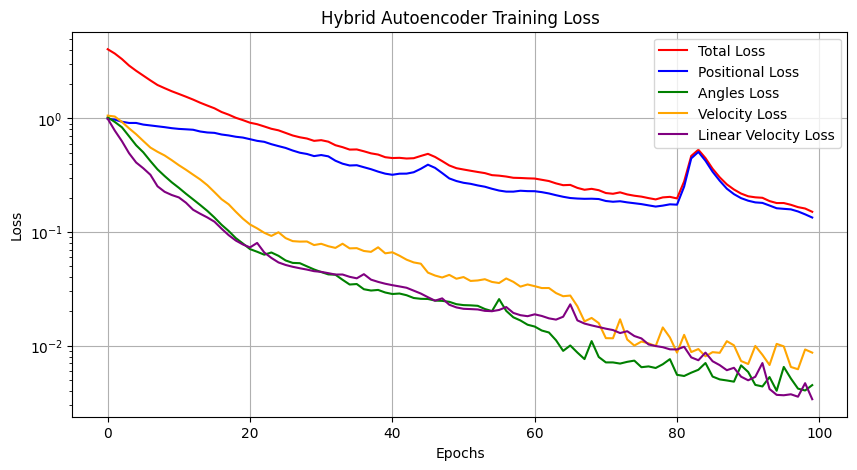

In [27]:
#show the losses, put labels, log scale the y axis
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(total_losses, label='Total Loss', color='red')
plt.plot(pos_losses, label='Positional Loss', color='blue')
plt.plot(angles_losses, label='Angles Loss', color='green')
plt.plot(vel_losses, label='Velocity Loss', color='orange')
plt.plot(lin_vel_losses, label='Linear Velocity Loss', color='purple')
plt.yscale('log')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Hybrid Autoencoder Training Loss')
plt.legend()
plt.grid(True)
plt.show()



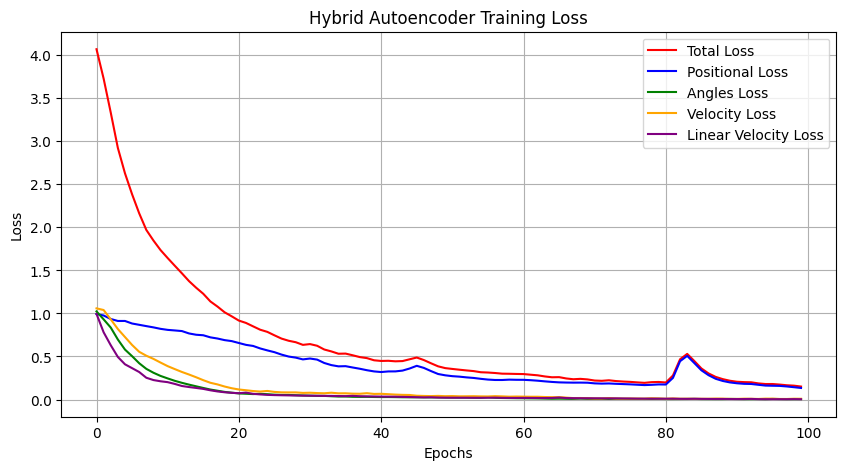

In [28]:
#show the losses, put labels, log scale the y axis
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(total_losses, label='Total Loss', color='red')
plt.plot(pos_losses, label='Positional Loss', color='blue')
plt.plot(angles_losses, label='Angles Loss', color='green')
plt.plot(vel_losses, label='Velocity Loss', color='orange')
plt.plot(lin_vel_losses, label='Linear Velocity Loss', color='purple')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Hybrid Autoencoder Training Loss')
plt.legend()
plt.grid(True)
plt.show()


In [15]:
#retrain from the saved model

# Initialize model, loss function, and optimizer
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')  # Set device to GPU if available

model = HybridAutoencoder().to(device)  # Move model to GPU
model.load_state_dict(torch.load('hybrid_autoencoder.pth'))
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Set the model to training mode
model.train()

# Define the number of epochs
num_epochs= 100


# Lists to store losses for each epoch
total_losses = []
pos_losses = []
angles_losses = []
vel_losses = []
lin_vel_losses = []

# Training loop
for epoch in range(num_epochs):
    total_loss = 0  # Track total loss over the epoch
    pos_loss_epoch = 0
    angles_loss_epoch = 0
    vel_loss_epoch = 0
    lin_vel_loss_epoch = 0

    for pos, angles, velocities, lin_vel, _ in dataloader:
        # Move input tensors to the same device as the model
        pos = pos.to(device)
        angles = angles.to(device)
        velocities = velocities.to(device)
        lin_vel = lin_vel.to(device)

        # Standardize the data before feeding into the model
        pos = standardize(pos, mean_pos, std_pos)
        angles = standardize(angles, mean_angles, std_angles)
        velocities = standardize(velocities, mean_vel, std_vel)
        lin_vel = standardize(lin_vel, mean_lin_vel, std_lin_vel)

        # Forward pass
        pos_out, angles_out, vel_out, lin_vel_out, latent = model(pos, angles, velocities, lin_vel)

        # Compute the reconstruction loss for each feature type
        loss_pos = loss_fn(pos_out, pos)  # Already on GPU
        loss_angles = loss_fn(angles_out, angles)
        loss_vel = loss_fn(vel_out, velocities)
        loss_lin_vel = loss_fn(lin_vel_out, lin_vel)

        # Total loss is the sum of individual losses
        loss = loss_pos + loss_angles + loss_vel + loss_lin_vel

        # Backward pass and optimization step
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Accumulate losses
        total_loss += loss.item()
        pos_loss_epoch += loss_pos.item()
        angles_loss_epoch += loss_angles.item()
        vel_loss_epoch += loss_vel.item()
        lin_vel_loss_epoch += loss_lin_vel.item()

    # Calculate average losses for the epoch
    avg_total_loss = total_loss / len(dataloader)
    avg_pos_loss = pos_loss_epoch / len(dataloader)
    avg_angles_loss = angles_loss_epoch / len(dataloader)
    avg_vel_loss = vel_loss_epoch / len(dataloader)
    avg_lin_vel_loss = lin_vel_loss_epoch / len(dataloader)

    # Append losses to the lists
    total_losses.append(avg_total_loss)
    pos_losses.append(avg_pos_loss)
    angles_losses.append(avg_angles_loss)
    vel_losses.append(avg_vel_loss)
    lin_vel_losses.append(avg_lin_vel_loss)

    # Print the average losses for the epoch
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_total_loss}')
    print(f'    Positional Loss: {avg_pos_loss}, Angles Loss: {avg_angles_loss}, '
          f'Velocity Loss: {avg_vel_loss}, Linear Velocity Loss: {avg_lin_vel_loss}')

#save the model
torch.save(model.state_dict(), 'hybrid_autoencoder.pth')
print("Model saved.")

#save the losses
losses = {
    'total_losses': total_losses,
    'pos_losses': pos_losses,
    'angles_losses': angles_losses,
    'vel_losses': vel_losses,
    'lin_vel_losses': lin_vel_losses
}

with open('losses.json', 'w') as f:
    json.dump(losses, f)

print("Losses saved.")

print("Training complete.")

Epoch [1/100], Loss: 0.7944306982190985
    Positional Loss: 0.2022841839413894, Angles Loss: 0.18740915732556268, Velocity Loss: 0.25428696628659964, Linear Velocity Loss: 0.15045039826317838
Epoch [2/100], Loss: 0.2996397677220796
    Positional Loss: 0.18235028888049878, Angles Loss: 0.03573828455256788, Velocity Loss: 0.05190767710538287, Linear Velocity Loss: 0.029643518507088486
Epoch [3/100], Loss: 0.20896226010824503
    Positional Loss: 0.15765160557470823, Angles Loss: 0.014533733556929388, Velocity Loss: 0.025405518220443474, Linear Velocity Loss: 0.011371401653281953
Epoch [4/100], Loss: 0.20103593562778674
    Positional Loss: 0.17157396595729024, Angles Loss: 0.008261069606401418, Velocity Loss: 0.014945901440162408, Linear Velocity Loss: 0.006254997079897868
Epoch [5/100], Loss: 0.17266949226981715
    Positional Loss: 0.15211960516477885, Angles Loss: 0.005918750049252259, Velocity Loss: 0.010017822177982643, Linear Velocity Loss: 0.004613316127736317
Epoch [6/100], Los

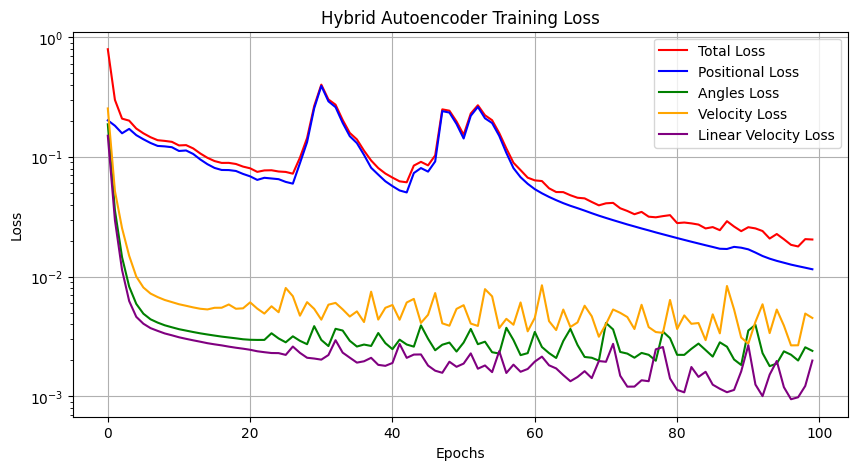

In [17]:
#show the losses, put labels, log scale the y axis
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(total_losses, label='Total Loss', color='red')
plt.plot(pos_losses, label='Positional Loss', color='blue')
plt.plot(angles_losses, label='Angles Loss', color='green')
plt.plot(vel_losses, label='Velocity Loss', color='orange')
plt.plot(lin_vel_losses, label='Linear Velocity Loss', color='purple')
plt.yscale('log')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Hybrid Autoencoder Training Loss')
plt.legend()
plt.grid(True)
plt.show()



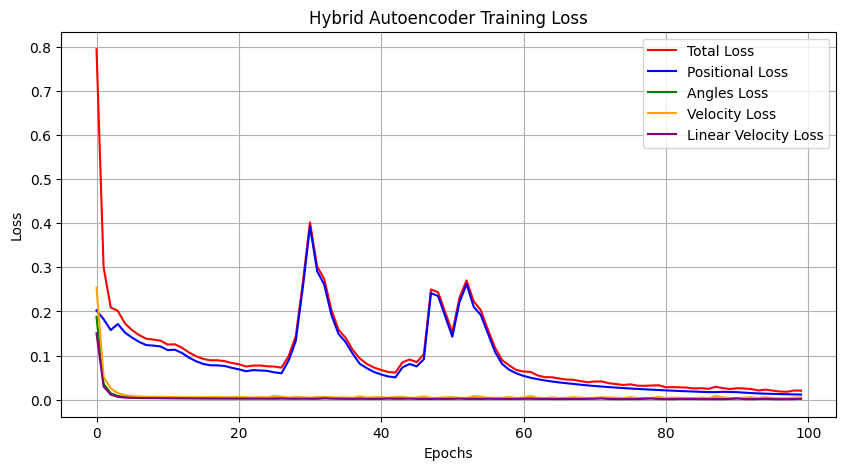

In [18]:
#show the losses, put labels, log scale the y axis
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(total_losses, label='Total Loss', color='red')
plt.plot(pos_losses, label='Positional Loss', color='blue')
plt.plot(angles_losses, label='Angles Loss', color='green')
plt.plot(vel_losses, label='Velocity Loss', color='orange')
plt.plot(lin_vel_losses, label='Linear Velocity Loss', color='purple')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Hybrid Autoencoder Training Loss')
plt.legend()
plt.grid(True)
plt.show()



In [41]:
#pick a random batch of data and store the latent space representation
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')  # Set device to GPU if available

model = HybridAutoencoder().to(device)  # Move model to GPU
model.load_state_dict(torch.load('AutoEncoder/pretrained/50_act/hybrid_autoencoder.pth'))
# Set the model to evaluation mode
model.eval()

# Get a random batch of data
pos, angles, velocities, lin_vel, id, windows_start = next(iter(dataloader))

# Move input tensors to the same device as the model
pos = pos.to(device)
angles = angles.to(device)
velocities = velocities.to(device)
lin_vel = lin_vel.to(device)

# Standardize the data before feeding into the model
pos = standardize(pos, mean_pos, std_pos)
angles = standardize(angles, mean_angles, std_angles)
velocities = standardize(velocities, mean_vel, std_vel)
lin_vel = standardize(lin_vel, mean_lin_vel, std_lin_vel)

# Forward pass
pos_out, angles_out, vel_out, lin_vel_out, latent = model(pos, angles, velocities, lin_vel)

# Move latent space representation to CPU
latent = latent.cpu().detach().numpy()


In [42]:
latent.shape

(32, 120, 256)

[0.1364139  0.08875448]


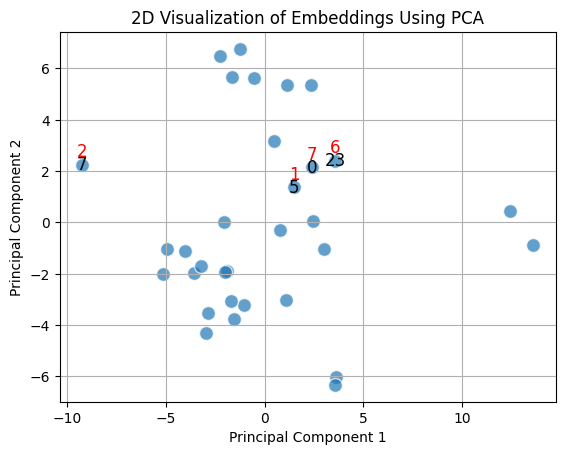

In [49]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Flatten the latent space data
flattened_data = latent.reshape(32, -1)

# Apply PCA to reduce to 2 components for visualization
pca = PCA(n_components=2)

reduced_data = pca.fit_transform(flattened_data)
print(pca.explained_variance_ratio_)

# Plot the reduced data
plt.scatter(reduced_data[:, 0], reduced_data[:, 1], alpha=0.7, edgecolors='w', s=100)
plt.title('2D Visualization of Embeddings Using PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)

# Add numbering to each point
for i, (x, y) in enumerate(reduced_data):
    if i in [7,5,0,23]:
        #add the player id[i] to the plot
        plt.text(x, y+0.5, id[i].split('_')[-1], fontsize=12, ha='center', va='center', color='red')
        plt.text(x, y, str(i), fontsize=12, ha='center', va='center', color='black')

plt.show()


In [45]:
import pandas as pd

# Example lists
id_list = id  # replace with your actual id_list
frame_list = windows_start  # replace with your actual frame_list

# Create a DataFrame
df = pd.DataFrame({
    'ID': id_list,
    'Frame': frame_list
})

# Display the DataFrame
index = [7,5,0,23]

list_to_analyze = [df.iloc[i] for i in index]
list_to_analyze

[ID       player_2
 Frame          40
 Name: 7, dtype: object,
 ID       player_1
 Frame         240
 Name: 5, dtype: object,
 ID       player_7
 Frame         280
 Name: 0, dtype: object,
 ID       player_6
 Frame          50
 Name: 23, dtype: object]

In [3]:
import cv2
from PIL import Image
import os

def parse_clip_txt(clip_txt_path):
    """
    Parse the clip.txt file to extract bounding box data for each frame and player.

    Args:
        clip_txt_path: The path to the clip.txt file.

    Returns:
        bbox_data: A dictionary where the key is a tuple (frame, player_id) and the value is a tuple (x, y, width, height).
    """
    bbox_data = {}
    
    with open(clip_txt_path, 'r') as file:
        for line in file:
            parts = line.strip().split(',')
            frame_num = int(parts[0])
            player_id = int(parts[1])
            x = float(parts[2])
            y = float(parts[3])
            width = float(parts[4])
            height = float(parts[5])
            bbox_data[(frame_num, player_id)] = (x, y, width, height)
    
    return bbox_data

def draw_bounding_box(image, x, y, width, height, color=(255, 0, 0), thickness=2):
    """
    Draw a bounding box on the image using OpenCV.

    Args:
        image: The OpenCV image object.
        x, y: The top-left coordinates of the bounding box.
        width, height: The width and height of the bounding box.
        color: The color of the bounding box (default: red).
        thickness: The thickness of the bounding box lines (default: 2).

    Returns:
        image: The image with the bounding box drawn.
    """
    start_point = (int(x), int(y))
    end_point = (int(x + width), int(y + height))
    image = cv2.rectangle(image, start_point, end_point, color, thickness)
    return image

def create_gif_from_frames(start_frame_path, player_id, output_gif_path, clip_txt_path, id_pca,num_frames=120, frame_duration=100):
    """
    Create a GIF from a starting frame and the next `num_frames` frames, adding bounding boxes from clip.txt.

    Args:
        start_frame_path: The path to the starting frame (must be a full path to the image).
        output_gif_path: The output path for the GIF file.
        clip_txt_path: The path to the clip.txt file containing bounding box information.
        num_frames: The number of consecutive frames to include in the GIF (default: 120).
        frame_duration: The duration of each frame in milliseconds (default: 100 ms).

    Returns:
        None: Saves the GIF to the specified output path.
    """
    # Parse bounding box data from clip.txt
    bbox_data = parse_clip_txt(clip_txt_path)

    print("end of parse_clip_txt")
    
    # Extract the directory and file name from the start frame path
    directory, start_frame = os.path.split(start_frame_path)
    
    # Find the starting frame number (assumes frames are named with numbers like 'frame_001.jpg')
    frame_num = int(''.join(filter(str.isdigit, start_frame)))
    
    # Create a list to store frames
    frames = []
    
    # Iterate over the next num_frames starting from the given frame
    for i in range(num_frames):
        frame_path = os.path.join(directory, f"frame_{frame_num + i:04}.jpg")  # Update this pattern as per your naming
        try:
            frame = cv2.imread(frame_path)
            # If the frame is successfully loaded
            if frame is not None:
                # Find the bounding box for the current frame and player_id
                if (frame_num + i, player_id) in bbox_data:
                    x, y, width, height = bbox_data[(frame_num + i, player_id)]
                    #print(x, y, width, height)
                    frame = draw_bounding_box(frame, x, y, width, height)
                
                #add id_pca at top left corner
                cv2.putText(frame, 'cluster id nbr : '+id_pca, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 2, cv2.LINE_AA)
                cv2.putText(frame, 'player number : '+str(player_id), (10, 60), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 2, cv2.LINE_AA)

                # Convert the BGR OpenCV frame to RGB and then to a PIL image
                frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                pil_image = Image.fromarray(frame_rgb)


                # Append the PIL image to the list of frames
                frames.append(pil_image)
            else:
                print(f"Frame {frame_path} could not be loaded. Skipping.")
        
        except FileNotFoundError:
            print(f"Frame {frame_path} not found. Skipping.")
    
    # Save the frames as a GIF
    if frames:
        output_gif_path = f'{output_gif_path}_{start_frame}_{id_pca}.gif'
        frames[0].save(output_gif_path, save_all=True, append_images=frames[1:], duration=frame_duration, loop=0)
        print(f"GIF saved as {output_gif_path}")
    else:
        print("No frames to create a GIF.")



In [ ]:
# Example usage
# Loop over list_to_analyze
action_name = str(460)


for i, row in enumerate(list_to_analyze):
    start_frame = f"{action_name}/frame_0{row['Frame']}.jpg"
    clip_path = f"{action_name}/clip.txt"
    create_gif_from_frames(start_frame, int(row['ID'].split('_')[1]), 'output', clip_path, str(row.name))


[0.1364138  0.08875444 0.06666733 0.05756696 0.05301724 0.04895266
 0.04193681 0.03941111 0.037185   0.03453272 0.03038649 0.02979237
 0.02840612 0.02769266 0.02525657 0.02417989 0.02356775 0.02265498
 0.02134792 0.01914826 0.01902146 0.0172616  0.01688704 0.01586201
 0.01513808]
Total Variance Explained by 10 components: 0.9410412721335888
Cluster assignments for each player: [2 0 2 2 2 0 4 3 2 1 1 2 1 0 1 0 2 2 1 2 0 2 0 4 2 2 2 4 0 0 2 1]


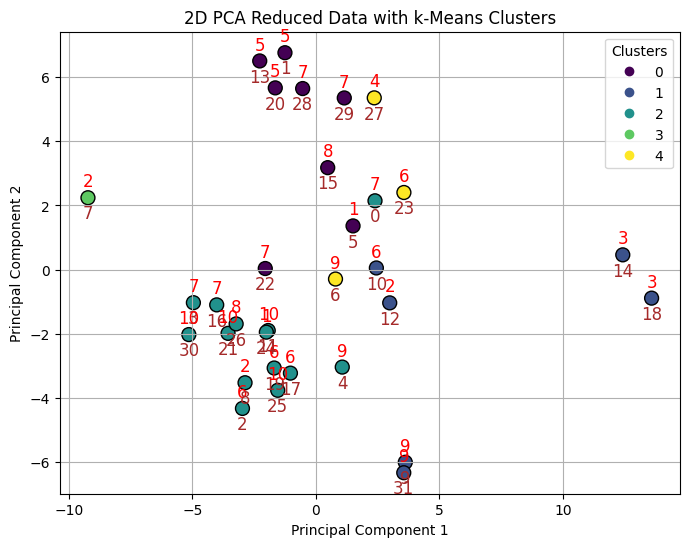

In [66]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import numpy as np

flattened_data = latent.reshape(32, -1)

pca = PCA(n_components=25)
reduced_data = pca.fit_transform(flattened_data)
explained_variance = pca.explained_variance_ratio_
print(explained_variance)
total_variance = sum(explained_variance)
print(f"Total Variance Explained by 10 components: {total_variance}")

kmeans = KMeans(n_clusters=5)  # Choose the number of clusters, e.g., 5
clusters = kmeans.fit_predict(reduced_data)

print("Cluster assignments for each player:", clusters)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(reduced_data[:, 0], reduced_data[:, 1], c=clusters, cmap='viridis', s=100, edgecolors='k')

plt.legend(*scatter.legend_elements(), title="Clusters")
plt.title('2D PCA Reduced Data with k-Means Clusters')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)

for i, (x, y) in enumerate(zip(reduced_data[:, 0], reduced_data[:, 1])):
    #if i in [7,5,0,23]:
        #add the player id[i] to the plot
    plt.text(x, y+0.5, id[i].split('_')[-1], fontsize=12, ha='center', va='center', color='red')
    plt.text(x, y-0.5, str(i), fontsize=12, ha='center', va='center', color='brown')

# Show plot
plt.show()

In [54]:
seuil_variance = 0.90
nb_composantes = np.argmax(explained_variance >= seuil_variance) + 1
print(f"Nombre de composantes pour expliquer {seuil_variance * 100}% de la variance : {nb_composantes}")

Nombre de composantes pour expliquer 90.0% de la variance : 1


In [67]:
id_list = id  # replace with your actual id_list
frame_list = windows_start  # replace with your actual frame_list

# Create a DataFrame
df = pd.DataFrame({
    'ID': id_list,
    'Frame': frame_list
})

# Display the DataFrame
index = [27,23,6,15]

list_to_analyze = [df.iloc[i] for i in index]
list_to_analyze

[ID       player_4
 Frame         210
 Name: 27, dtype: object,
 ID       player_6
 Frame          50
 Name: 23, dtype: object,
 ID       player_9
 Frame          20
 Name: 6, dtype: object,
 ID       player_8
 Frame         350
 Name: 15, dtype: object]

In [68]:
action_name = str(460)


for i, row in enumerate(list_to_analyze):
    start_frame = f"{action_name}/frame_0{row['Frame']}.jpg"
    clip_path = f"{action_name}/clip.txt"
    create_gif_from_frames(start_frame, int(row['ID'].split('_')[1]), 'output', clip_path, str(row.name))

end of parse_clip_txt
GIF saved as output_frame_0210.jpg_27.gif
end of parse_clip_txt
GIF saved as output_frame_050.jpg_23.gif
end of parse_clip_txt
GIF saved as output_frame_020.jpg_6.gif
end of parse_clip_txt
GIF saved as output_frame_0350.jpg_15.gif


### SHOW OUTPUT LOSS TRAINING

dict_keys(['total_losses', 'pos_losses', 'angles_losses', 'vel_losses', 'lin_vel_losses'])


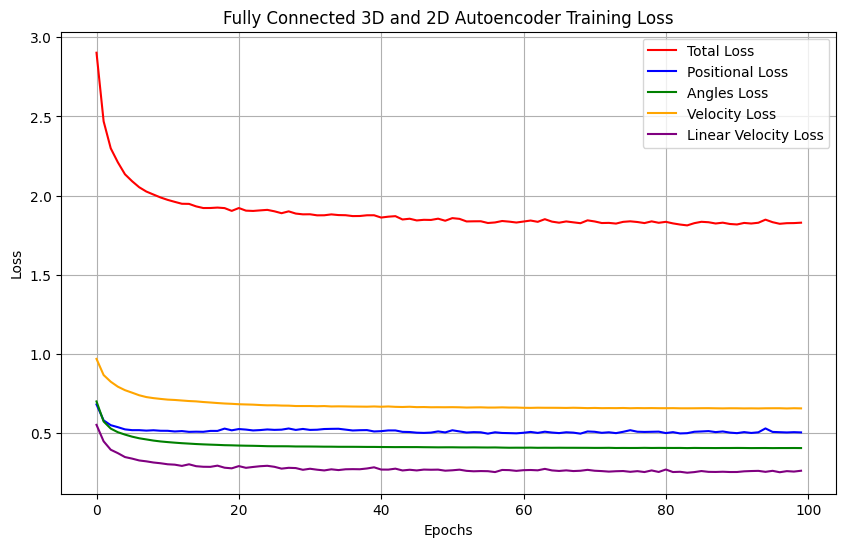

In [83]:
#load the losses 
import json
import matplotlib.pyplot as plt

path_loss = 'losses/FC/losses_new.json'


name_model = 'Fully Connected 3D and 2D'

with open(path_loss, 'r') as f:
    losses = json.load(f)

print(losses.keys())

# Plot the losses
total_losses = losses['total_losses']
pos_losses = losses['pos_losses']
angles_losses = losses['angles_losses']
vel_losses = losses['vel_losses']
#acc_losses = losses['acc_losses']
lin_vel_losses = losses['lin_vel_losses']



import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(total_losses, label='Total Loss', color='red')
plt.plot(pos_losses, label='Positional Loss', color='blue')
plt.plot(angles_losses, label='Angles Loss', color='green')
plt.plot(vel_losses, label='Velocity Loss', color='orange')
plt.plot(lin_vel_losses, label='Linear Velocity Loss', color='purple')
#plt.plot(acc_losses, label='Acceleration Loss', color='brown')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title(f'{name_model} Autoencoder Training Loss')
plt.legend()
plt.grid(True)
plt.show()




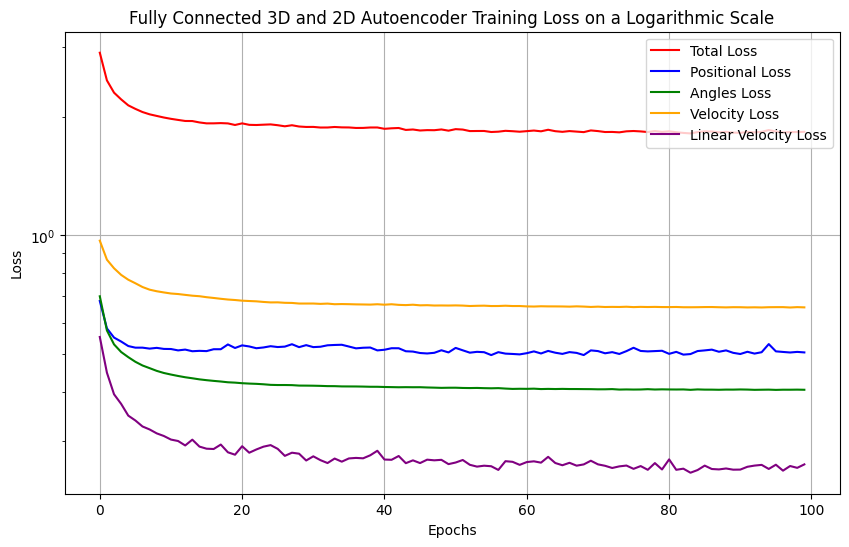

In [84]:
plt.figure(figsize=(10, 6))
plt.plot(total_losses, label='Total Loss', color='red')
plt.plot(pos_losses, label='Positional Loss', color='blue')
plt.plot(angles_losses, label='Angles Loss', color='green')
plt.plot(vel_losses, label='Velocity Loss', color='orange')
plt.plot(lin_vel_losses, label='Linear Velocity Loss', color='purple')
#plt.plot(acc_losses, label='Acceleration Loss', color='brown')
plt.yscale('log')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title(f'{name_model} Autoencoder Training Loss on a Logarithmic Scale')
plt.legend()
plt.grid(True)
plt.show()

In [77]:
#load the npy

path_dist = "/Users/strom/Desktop/test_jump/frame_286/npy/all_jump_dist.npy"

path_class_dist = "/Users/strom/Desktop/test_jump/frame_286/npy/all_jump_cls.npy"

path_pkl = "/Users/strom/Desktop/test_jump/frame_286/npy/img_paths.pkl"



dist = np.load(path_dist)
class_dist = np.load(path_class_dist)
pkl = pd.read_pickle(path_pkl)

In [78]:
dist

array([0.03325649, 0.45595556, 0.02297451, 0.16856138, 0.47863197,
       0.04596982, 0.51177418])

In [79]:
class_dist

array([0, 1, 0, 0, 1, 0, 1], dtype=int64)

In [80]:
pkl

['/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/aandre/datasets/Input_Model/CHI_NYK/586/frame_286/img_crop/frame_0001.png',
 '/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/aandre/datasets/Input_Model/CHI_NYK/586/frame_286/img_crop/frame_0006.png',
 '/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/aandre/datasets/Input_Model/CHI_NYK/586/frame_286/img_crop/frame_0000.png',
 '/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/aandre/datasets/Input_Model/CHI_NYK/586/frame_286/img_crop/frame_0005.png',
 '/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/aandre/datasets/Input_Model/CHI_NYK/586/frame_286/img_crop/frame_0004.png',
 '/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/aandre/datasets/Input_Model/CHI_NYK/586/frame_286/img_crop/frame_0003.png',
 '/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/aandre/datasets/Input_Model/CHI_NYK/586/frame_286/img_crop/frame_0002.png']

In [22]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("/Users/strom/Desktop/fultz_2s/frame_0001.jpg")



In [23]:
import json
path_data_players = "/Users/strom/Desktop/clip_injuries/2s/fultz_2s.json"

with open(path_data_players) as f:
    data = json.load(f)

bbox = data['action_data']['players']['player_2']['frames'][0]['bbox']
bbox

KeyError: 'action_data'

In [24]:
import json
path_data_players = "/Users/strom/Desktop/clip_injuries/2s/fultz_2s.json"

with open(path_data_players) as f:
    data = json.load(f)

data.keys()

dict_keys(['player_id', 'frames'])

In [35]:
import numpy as np

np.array(data['frames'][0]['j3d_human']['coordinates']).shape

(35, 3)

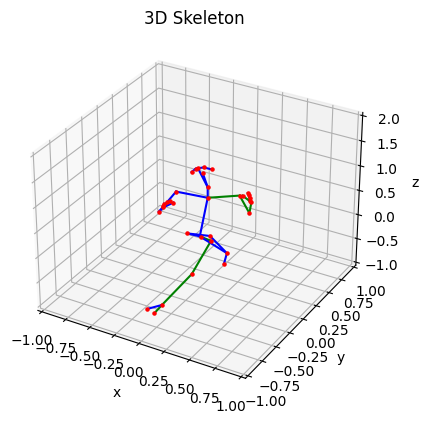

In [36]:
def plot_3d_skeleton(joints_3d, parent_ids, ax, 
                     c0='r', c1='b', c2='g', 
                     right_joint_list=[1, 2, 3, 13, 14, 15, 16, 17, 18, 19, 20, 21]):
    X = joints_3d[:, 0]
    Y = joints_3d[:, 1]
    Z = joints_3d[:, 2]
    
    for i in range(1, joints_3d.shape[0]):
        ax.scatter(X[i], Y[i], Z[i], c=c0, marker='.')
        x = np.array([X[i], X[parent_ids[i]]], dtype=np.float32)
        y = np.array([Y[i], Y[parent_ids[i]]], dtype=np.float32)
        z = np.array([Z[i], Z[parent_ids[i]]], dtype=np.float32)
        c = c2 if i in right_joint_list else c1
        ax.plot(x, y, z, c=c)

    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    ax.set_zlim(-1, 2)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')
    ax.grid(True)
    ax.set_title('3D Skeleton')

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Example data
joints_3d = np.array(data['frames'][0]['j3d_human']['coordinates'])
parents = np.array([-1,0,1,2,0,4,5,0,7,8,7,10,11,7,13,14,
            15,15,15,15,15,3,3,34,23,12,12,12,12,12,6,6,34,32,8])
parent_ids = parents

plot_3d_skeleton(joints_3d, parent_ids, ax)
plt.show()

In [228]:
liste =[[bbox['x'],bbox['y'],bbox['width'],bbox['height']]]


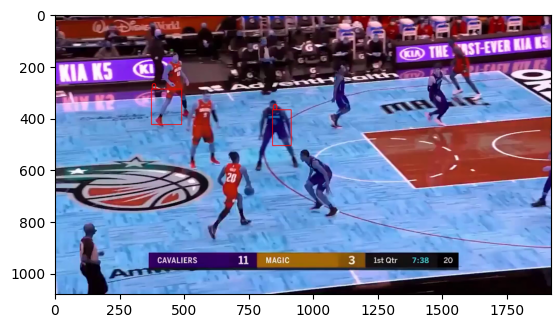

In [229]:
for y, i in enumerate(liste):
    img = draw_bounding_box(img, i[0], i[1], i[2], i[3])
    
    #add number y to the plot
    cv2.putText(img, str(y), (int(i[0]), int(i[1])), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 2, cv2.LINE_AA)


plt.imshow(img)

In [189]:
#keep the 120 frames since the frame 240

for i, datas in enumerate(data['action_data']['players']['player_9']['frames']):
    if datas['frame_number'] == 73:
        index = i
        break

data['action_data']['players']['player_9']['frames'] = data['action_data']['players']['player_9']['frames'][index:index+120]

In [190]:
len(data['action_data']['players']['player_9']['frames'])

120

In [191]:
#save only the player_2 from data

path_data_players_save = "/Users/strom/Desktop/153/stepback.json"

with open(path_data_players_save, 'w') as f:
    json.dump(data['action_data']['players']['player_9'], f)


In [101]:
#create random np array with shape (120, 20)

import numpy as np

np.random.seed(0)
data = np.random.rand(120, 20)
velocity_threshold = 0.5
np.where(data > velocity_threshold)

(array([  0,   0,   0, ..., 119, 119, 119], dtype=int64),
 array([ 0,  1,  2, ..., 12, 18, 19], dtype=int64))

In [85]:
#load the npy

path_dist = "/Users/strom/Desktop/test_jump/frame_287/npy/all_jump_dist.npy"

path_class_dist = "/Users/strom/Desktop/test_jump/frame_287/npy/all_jump_cls.npy"

path_pkl = "/Users/strom/Desktop/test_jump/frame_287/npy/img_paths.pkl"



dist = np.load(path_dist)
class_dist = np.load(path_class_dist)
pkl = pd.read_pickle(path_pkl)
dist, class_dist, pkl

(array([0.53931612, 0.0291695 , 0.02935039, 0.33747303, 0.13152738,
        0.49612141, 0.05573055]),
 array([1, 0, 0, 1, 0, 1, 0], dtype=int64),
 ['/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/aandre/datasets/Input_Model/CHI_NYK/586/frame_287/img_crop/frame_0001.png',
  '/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/aandre/datasets/Input_Model/CHI_NYK/586/frame_287/img_crop/frame_0006.png',
  '/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/aandre/datasets/Input_Model/CHI_NYK/586/frame_287/img_crop/frame_0000.png',
  '/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/aandre/datasets/Input_Model/CHI_NYK/586/frame_287/img_crop/frame_0005.png',
  '/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/aandre/datasets/Input_Model/CHI_NYK/586/frame_287/img_crop/frame_0004.png',
  '/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/aandre/datasets/Input_Model/CHI_NYK/586/frame_287/img_crop/frame_0003.png',
  '/n/holylfs05/LABS/pfist

: 

In [37]:
#open the json
import json

path_data_players = "/Users/strom/Desktop/test_loss/similarity_results_pca_fultz.json"
path_data_players = "/Users/strom/Desktop//3D_features_5_GRU/defense_shoot/similarity_results_pca_feat.json"
#path_data_players = "/Users/strom/Desktop/SIMILARITY_OUTPUT/no_pca/3D_features_5_LSTM_DN_FC/defense_shoot/similarity_results_no_pca.json"


with open(path_data_players) as f:
    data = json.load(f)


In [38]:
#put json in a dataframe
import pandas as pd

df = pd.DataFrame(data)
df.columns

Index(['match', 'action', 'first_frame', 'player_id', 'cosine_per_feature',
       'euclidean_per_feature', 'custom_combination'],
      dtype='object')

In [41]:
df['cosine_all'] = df['cosine_per_feature'].apply(lambda x: sum(x.values()))
df_test = df[['match', 'action', 'first_frame', 'player_id', 'cosine_all']].sort_values(by='cosine_all').drop_duplicates(['match', 'action', 'player_id']).reset_index(drop=True)

In [42]:
df_test.head()

,match,action,first_frame,player_id,cosine_all
0,CHI_NYK,410,121,player_9,3.124976
1,POR_SAC,204,340,player_12,3.333378
2,CHI_NYK,200,211,player_7,3.339605
3,CHI_NYK,392,573,player_9,3.350482
4,CHI_NYK,391,573,player_9,3.350482


In [213]:
df_cosine = df[['match','action', 'first_frame', 'player_id','cosine_per_feature']]
df_cosine = df_cosine.sort_values(by=['cosine'], ascending=True).reset_index(drop=True)

df_euclidean = df[['match','action', 'first_frame', 'player_id','euclidean']]
df_euclidean = df_euclidean.sort_values(by=['euclidean'], ascending=True).reset_index(drop=True)

df_mahalanobis = df[['match','action', 'first_frame', 'player_id','mahalanobis']]
df_mahalanobis = df_mahalanobis.sort_values(by=['mahalanobis'], ascending=True).reset_index(drop=True)

df_dtw = df[['match','action', 'first_frame', 'player_id','dtw']]
df_dtw = df_dtw.sort_values(by=['dtw'], ascending=True).reset_index(drop=True)

In [3]:
df['cosine_combined'] = df['cosine_per_feature'].apply(lambda x: sum(x.values()))

# Sort DataFrames by each combined score in ascending order and remove duplicates
df_cosine_combined = (
    df[['match', 'action', 'first_frame', 'player_id', 'cosine_combined']]
    .sort_values(by='cosine_combined')
    .drop_duplicates(subset=['match', 'action', 'player_id'])
    .reset_index(drop=True)
)

In [4]:
df_cosine_combined.head(5)

,match,action,first_frame,player_id,cosine_combined
0,PAC_ATL,571,181,player_5,2.902981
1,PAC_ATL,572,181,player_5,2.902981
2,CHI_NYK,514,301,player_5,2.921082
3,CHI_NYK,326,151,player_10,2.968854
4,CHI_NYK,328,151,player_10,2.968854


In [195]:
closest_actions = pd.concat([
    df_cosine.head(3),            # First 3 rows
    df_cosine.loc[[50, 500, 1500, 30000]]  # Rows with indices 50, 500, 1500, 30000
])

In [199]:
for i, j in closest_actions.iterrows():
    print(i)


0
1
2
50
500
1500
30000


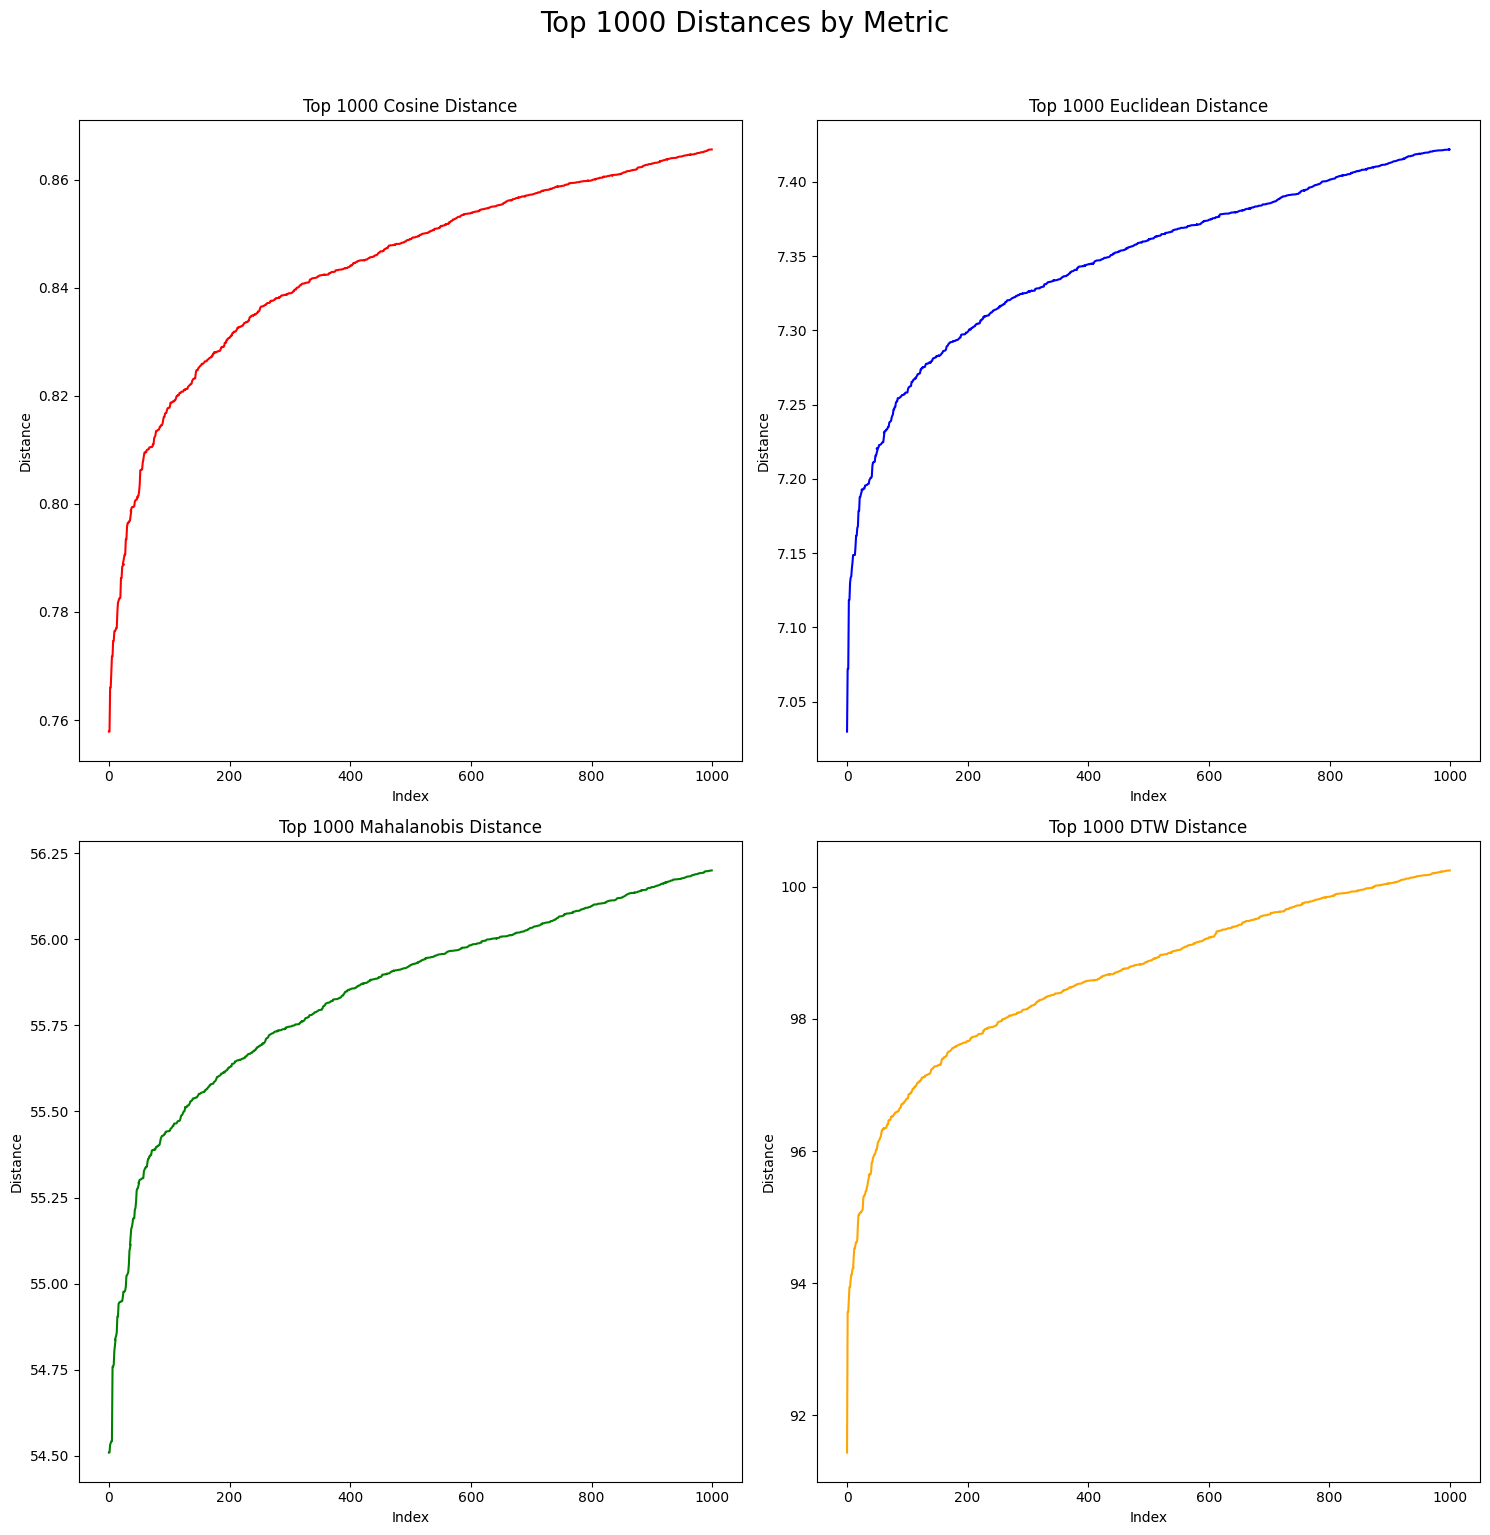

In [118]:
import matplotlib.pyplot as plt

# Sample the top 1000 values based on sorted distance for each metric
top_n = 1000

df_cosine_sorted = df_cosine.sort_values(by='cosine').head(top_n)
df_euclidean_sorted = df_euclidean.sort_values(by='euclidean').head(top_n)
df_mahalanobis_sorted = df_mahalanobis.sort_values(by='mahalanobis').head(top_n)
df_dtw_sorted = df_dtw.sort_values(by='dtw').head(top_n)

# Create 2x2 subplots
fig, axs = plt.subplots(2, 2, figsize=(15, 15))

# Add a global title for the figure
fig.suptitle('Top 1000 Distances by Metric', fontsize=20, y=1.02)

# Cosine Distance
axs[0, 0].plot(df_cosine_sorted.index, df_cosine_sorted['cosine'], color='red')
axs[0, 0].set_title('Top 1000 Cosine Distance')
axs[0, 0].set_xlabel('Index')
axs[0, 0].set_ylabel('Distance')

# Euclidean Distance
axs[0, 1].plot(df_euclidean_sorted.index, df_euclidean_sorted['euclidean'], color='blue')
axs[0, 1].set_title('Top 1000 Euclidean Distance')
axs[0, 1].set_xlabel('Index')
axs[0, 1].set_ylabel('Distance')

# Mahalanobis Distance
axs[1, 0].plot(df_mahalanobis_sorted.index, df_mahalanobis_sorted['mahalanobis'], color='green')
axs[1, 0].set_title('Top 1000 Mahalanobis Distance')
axs[1, 0].set_xlabel('Index')
axs[1, 0].set_ylabel('Distance')

# DTW Distance
axs[1, 1].plot(df_dtw_sorted.index, df_dtw_sorted['dtw'], color='orange')
axs[1, 1].set_title('Top 1000 DTW Distance')
axs[1, 1].set_xlabel('Index')
axs[1, 1].set_ylabel('Distance')

plt.tight_layout()
plt.show()



In [8]:
df_cosine.head(3)

,action,first_frame,player_id,cosine
0,28,67,player_2,0.757871
1,29,67,player_2,0.757871
2,269,151,player_7,0.766024


In [9]:
df_euclidean.head(3)

,action,first_frame,player_id,euclidean
0,330,121,player_2,7.029788
1,282,391,player_6,7.072016
2,281,391,player_6,7.072016


In [10]:
df_mahalanobis.head(3)

,action,first_frame,player_id,mahalanobis
0,243,301,player_2,54.509178
1,242,301,player_2,54.509178
2,426,322,player_5,54.532052


In [13]:
df_dtw.head(3)

,action,first_frame,player_id,dtw
0,481,241,player_3,91.437709
1,81,1,player_11,93.566836
2,80,1,player_11,93.566836


In [5]:
import cv2
from PIL import Image
import os

def parse_clip_txt(clip_txt_path):
    """
    Parse the clip.txt file to extract bounding box data for each frame and player.

    Args:
        clip_txt_path: The path to the clip.txt file.

    Returns:
        bbox_data: A dictionary where the key is a tuple (frame, player_id) and the value is a tuple (x, y, width, height).
    """
    bbox_data = {}
    
    with open(clip_txt_path, 'r') as file:
        for line in file:
            parts = line.strip().split(',')
            frame_num = int(parts[0])
            player_id = int(parts[1])
            x = float(parts[2])
            y = float(parts[3])
            width = float(parts[4])
            height = float(parts[5])
            bbox_data[(frame_num, player_id)] = (x, y, width, height)
    
    return bbox_data

def draw_bounding_box(image, x, y, width, height, color=(255, 0, 0), thickness=2):
    """
    Draw a bounding box on the image using OpenCV.

    Args:
        image: The OpenCV image object.
        x, y: The top-left coordinates of the bounding box.
        width, height: The width and height of the bounding box.
        color: The color of the bounding box (default: red).
        thickness: The thickness of the bounding box lines (default: 2).

    Returns:
        image: The image with the bounding box drawn.
    """
    start_point = (int(x), int(y))
    end_point = (int(x + width), int(y + height))
    image = cv2.rectangle(image, start_point, end_point, color, thickness)
    return image

def create_gif_from_video(video_path, first_frame_num, player_id, output_gif_path, clip_txt_path, num_frames=120, frame_duration=100):
    """
    Create a GIF from a video, starting from `first_frame_num` and processing `num_frames` frames, 
    adding bounding boxes from clip.txt.

    Args:
        video_path: The path to the video file (mp4).
        first_frame_num: The starting frame number from the video.
        output_gif_path: The output path for the GIF file.
        clip_txt_path: The path to the clip.txt file containing bounding box information.
        num_frames: The number of consecutive frames to include in the GIF (default: 120).
        frame_duration: The duration of each frame in milliseconds (default: 100 ms).

    Returns:
        None: Saves the GIF to the specified output path.
    """
    # Parse bounding box data from clip.txt
    bbox_data = parse_clip_txt(clip_txt_path)

    # Open the video file
    cap = cv2.VideoCapture(video_path)
    
    # Set the video to start at the first_frame_num
    cap.set(cv2.CAP_PROP_POS_FRAMES, first_frame_num)

    # Check if the video was opened successfully
    if not cap.isOpened():
        print(f"Error opening video file: {video_path}")
        return

    # Create a list to store frames
    frames = []
    
    # Iterate over the next num_frames starting from the given frame
    for i in range(num_frames):
        ret, frame = cap.read()
        if not ret:
            print(f"Frame {first_frame_num + i} could not be read from video. Stopping.")
            break
        
        # Find the bounding box for the current frame and player_id
        if (first_frame_num + i, player_id) in bbox_data:
            x, y, width, height = bbox_data[(first_frame_num + i, player_id)]
            frame = draw_bounding_box(frame, x, y, width, height)

        cv2.putText(frame, f'player number : {player_id}', (10, 60), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 2, cv2.LINE_AA)

        # Convert the BGR OpenCV frame to RGB and then to a PIL image
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        pil_image = Image.fromarray(frame_rgb)

        # Append the PIL image to the list of frames
        frames.append(pil_image)

    # Release the video capture object
    cap.release()

    # Save the frames as a GIF
    if frames:
        output_gif_path = f'{output_gif_path}/frame_{first_frame_num}.gif'
        frames[0].save(output_gif_path, save_all=True, append_images=frames[1:], duration=frame_duration, loop=0)
        print(f"GIF saved as {output_gif_path}")
    else:
        print("No frames to create a GIF.")



In [6]:
df_cosine_combined.head(5)

,match,action,first_frame,player_id,cosine_combined
0,PAC_ATL,571,181,player_5,2.902981
1,PAC_ATL,572,181,player_5,2.902981
2,CHI_NYK,514,301,player_5,2.921082
3,CHI_NYK,326,151,player_10,2.968854
4,CHI_NYK,328,151,player_10,2.968854


In [18]:
action_name = df_cosine_combined['action'][0]
video_path = f'PAC_ATL/{str(action_name)}.mp4'
first_frame_num = int(df_cosine_combined['first_frame'][0]-35)  # The starting frame number in the video
player_id = int(df_cosine_combined['player_id'][0].split('_')[-1].strip())+3  # The player ID
output_gif_path = 'SIMILARITY_OUTPUT'
clip_txt_path = 'clip.txt'

create_gif_from_video(video_path, first_frame_num, player_id, output_gif_path, clip_txt_path)

GIF saved as SIMILARITY_OUTPUT/frame_146.gif


In [21]:
action_name = df_cosine_combined['action'][0]
video_path = f'PAC_ATL/{str(action_name)}.mp4'
first_frame_num = int(df_cosine_combined['first_frame'][0]-30)  # The starting frame number in the video
player_id = int(df_cosine_combined['player_id'][0].split('_')[-1].strip())+5  # The player ID
output_gif_path = 'SIMILARITY_OUTPUT'
clip_txt_path = 'clip.txt'

create_gif_from_video(video_path, first_frame_num, player_id, output_gif_path, clip_txt_path)

GIF saved as SIMILARITY_OUTPUT/frame_151.gif


In [14]:
action_name = df_cosine['action'][0]
video_path = f'CHI_NYK/{str(action_name)}.mp4'
first_frame_num = int(df_cosine['first_frame'][0])  # The starting frame number in the video
player_id = int(df_cosine['player_id'][0].split('_')[-1].strip())  # The player ID
output_gif_path = 'output_gif'
clip_txt_path = 'clip.txt'

create_gif_from_video(video_path, first_frame_num, player_id, output_gif_path, clip_txt_path)

NameError: name 'df_cosine' is not defined

In [110]:
data = [1, 2, 3, 4, 5]
mean = [1, 9, 3, 7, 5]
std = [0.1, 0.2, 0.3, 0.4, 0.5]

def standardize(data, mean, std):
    data = np.array(data)
    mean = np.array(mean)
    std = np.array(std)
    return ((data - mean) / std).tolist()


[0.0, -35.0, 0.0, -7.5, 0.0]


Loaded 10 2D metric files and 10 3D metric files.


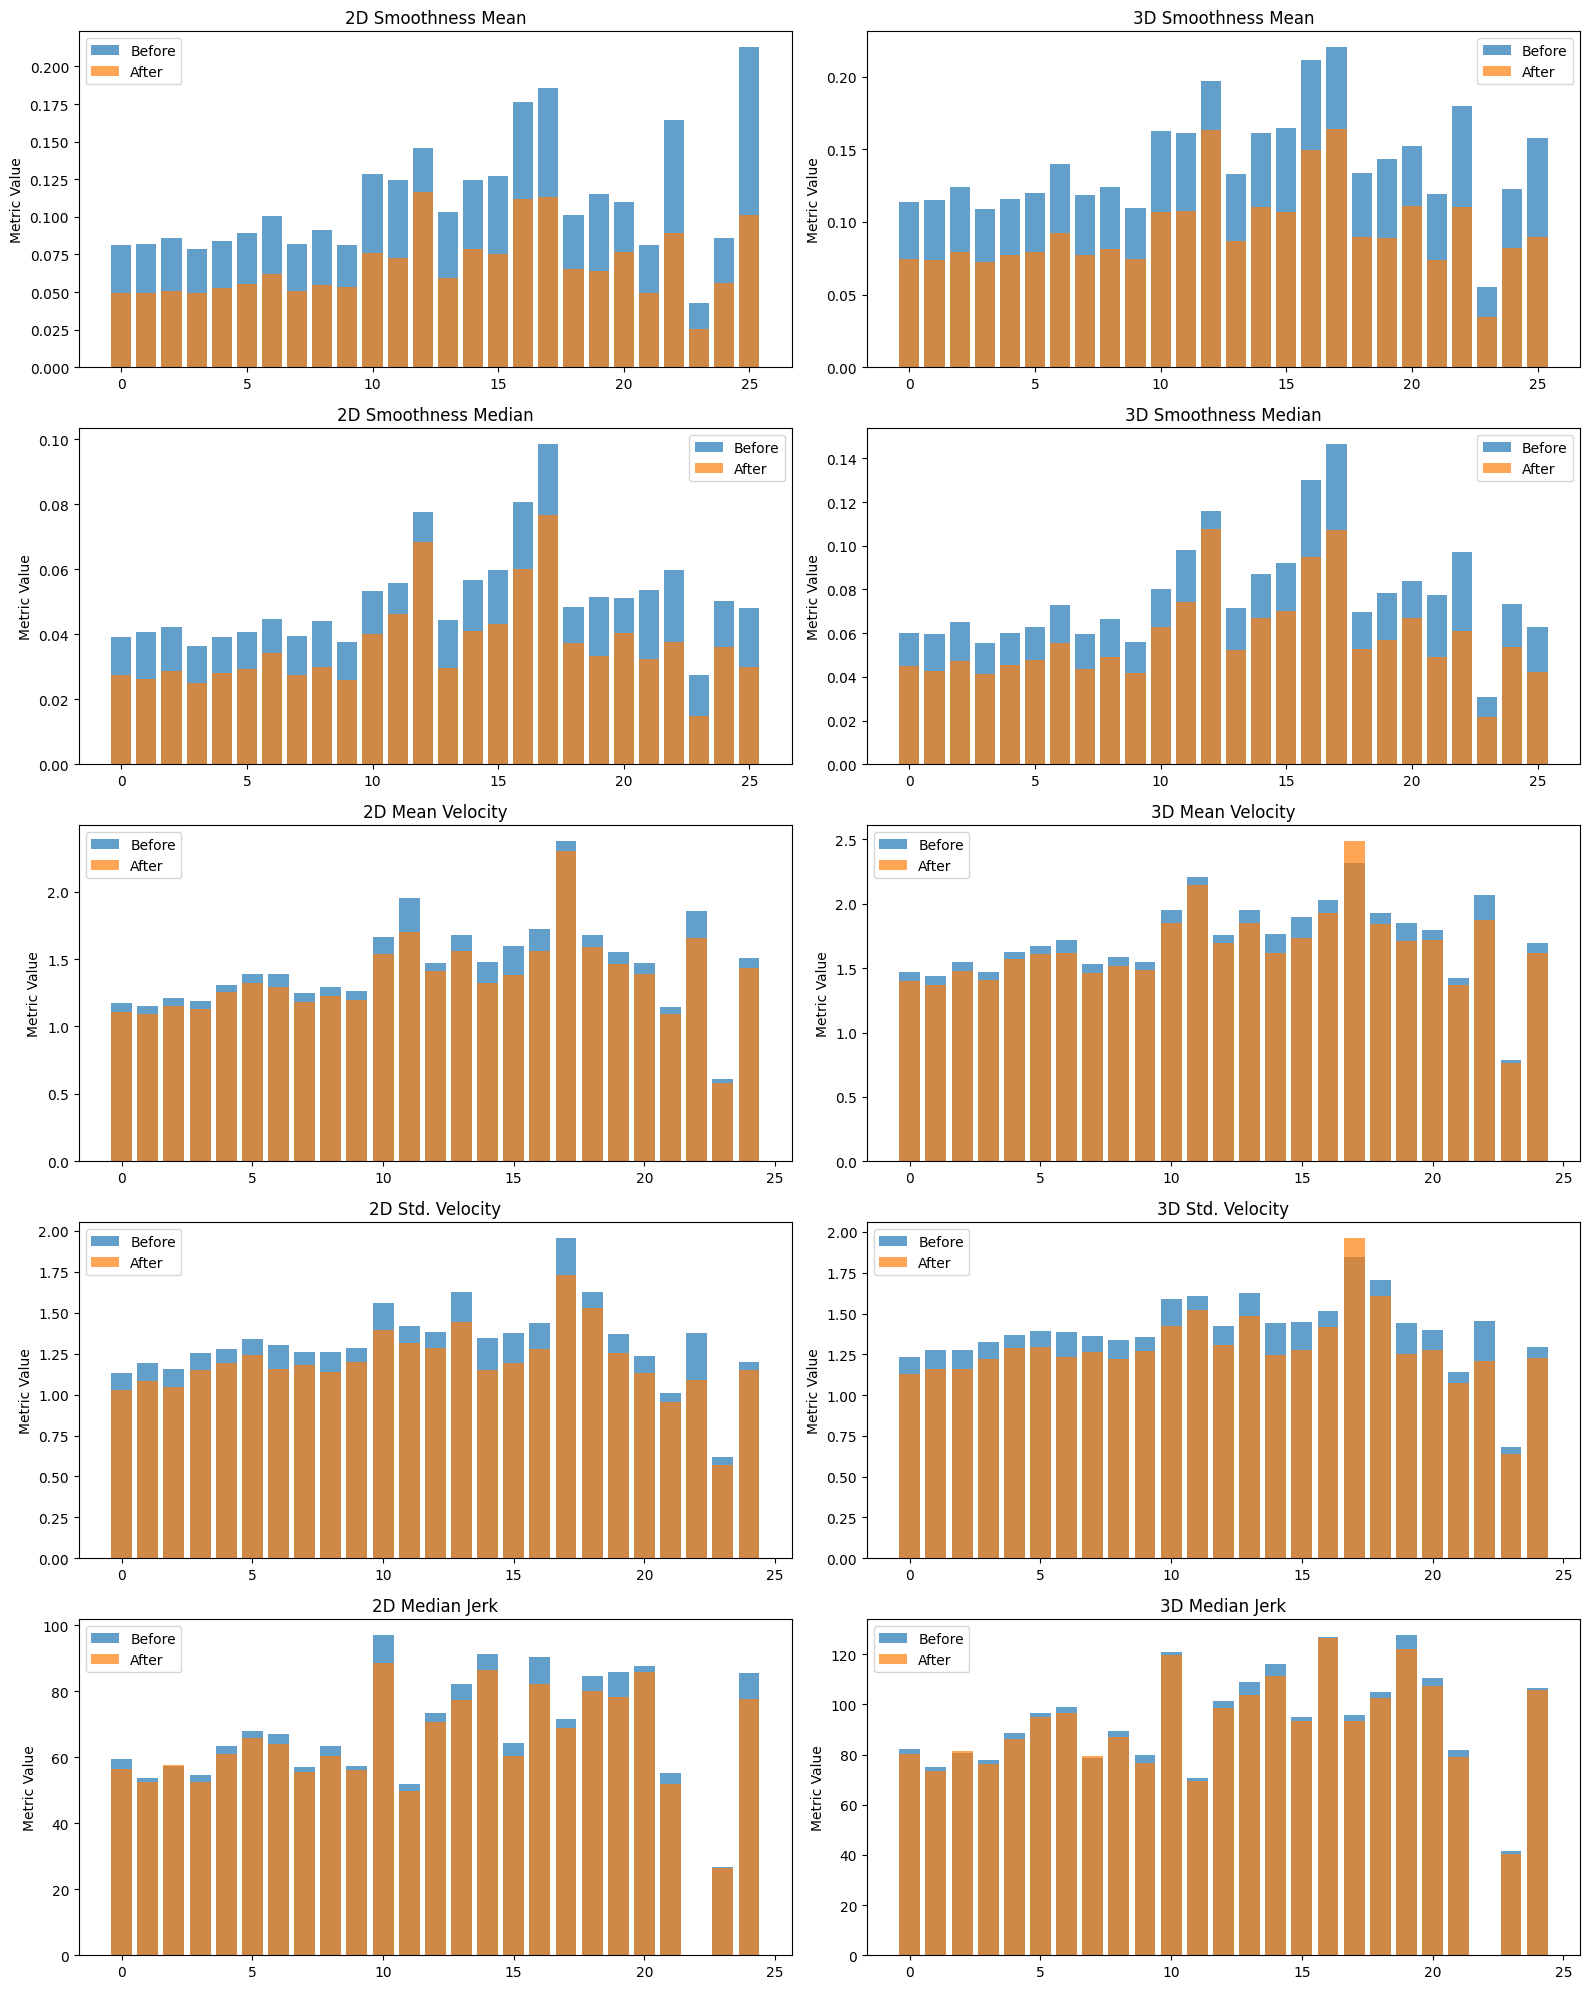

In [86]:
import pandas as pd
import matplotlib.pyplot as plt
import json
import os

# Function to load JSON files from a directory
def load_json_files(directory):
    data = []
    for filename in os.listdir(directory):
        if filename.endswith('.json'):
            with open(os.path.join(directory, filename), 'r') as file:
                data.append(json.load(file))
    return data

# Function to extract metric values for plotting
def extract_metric_values(metric_data, metric_name):
    before_values = [entry[metric_name]['before'] for entry in metric_data]
    after_values = [entry[metric_name]['after'] for entry in metric_data]
    return pd.DataFrame(before_values).mean(), pd.DataFrame(after_values).mean()

# Define paths for 2D and 3D metric directories
path_2d = 'kalman_metrics/2D/'  # Replace with your 2D JSON directory path
path_3d = 'kalman_metrics/3D/'  # Replace with your 3D JSON directory path

# Load data from the 2D and 3D directories
metrics_2d = load_json_files(path_2d)
metrics_3d = load_json_files(path_3d)

print(f'Loaded {len(metrics_2d)} 2D metric files and {len(metrics_3d)} 3D metric files.')

# Metrics to plot
metrics_to_plot = ['smoothness_mean', 'smoothness_median', 'mean_velocity', 'std_velocity', 'median_jerk']
metric_names = {
    'smoothness_mean': 'Smoothness Mean',
    'smoothness_median': 'Smoothness Median',
    'mean_velocity': 'Mean Velocity',
    'std_velocity': 'Std. Velocity',
    'median_jerk': 'Median Jerk'
}

# Plot metrics for both 2D and 3D data
fig, axes = plt.subplots(len(metrics_to_plot), 2, figsize=(16, 20))
for i, metric in enumerate(metrics_to_plot):
    # Extract metric values for 2D and 3D
    before_2d, after_2d = extract_metric_values(metrics_2d, metric)
    before_3d, after_3d = extract_metric_values(metrics_3d, metric)
    
    # Plot 2D metrics
    axes[i, 0].bar(before_2d.index, before_2d, label='Before', alpha=0.7)
    axes[i, 0].bar(after_2d.index, after_2d, label='After', alpha=0.7)
    axes[i, 0].set_title(f'2D {metric_names[metric]}')
    axes[i, 0].set_ylabel('Metric Value')
    axes[i, 0].legend()
    
    # Plot 3D metrics
    axes[i, 1].bar(before_3d.index, before_3d, label='Before', alpha=0.7)
    axes[i, 1].bar(after_3d.index, after_3d, label='After', alpha=0.7)
    axes[i, 1].set_title(f'3D {metric_names[metric]}')
    axes[i, 1].set_ylabel('Metric Value')
    axes[i, 1].legend()

plt.tight_layout()
plt.show()


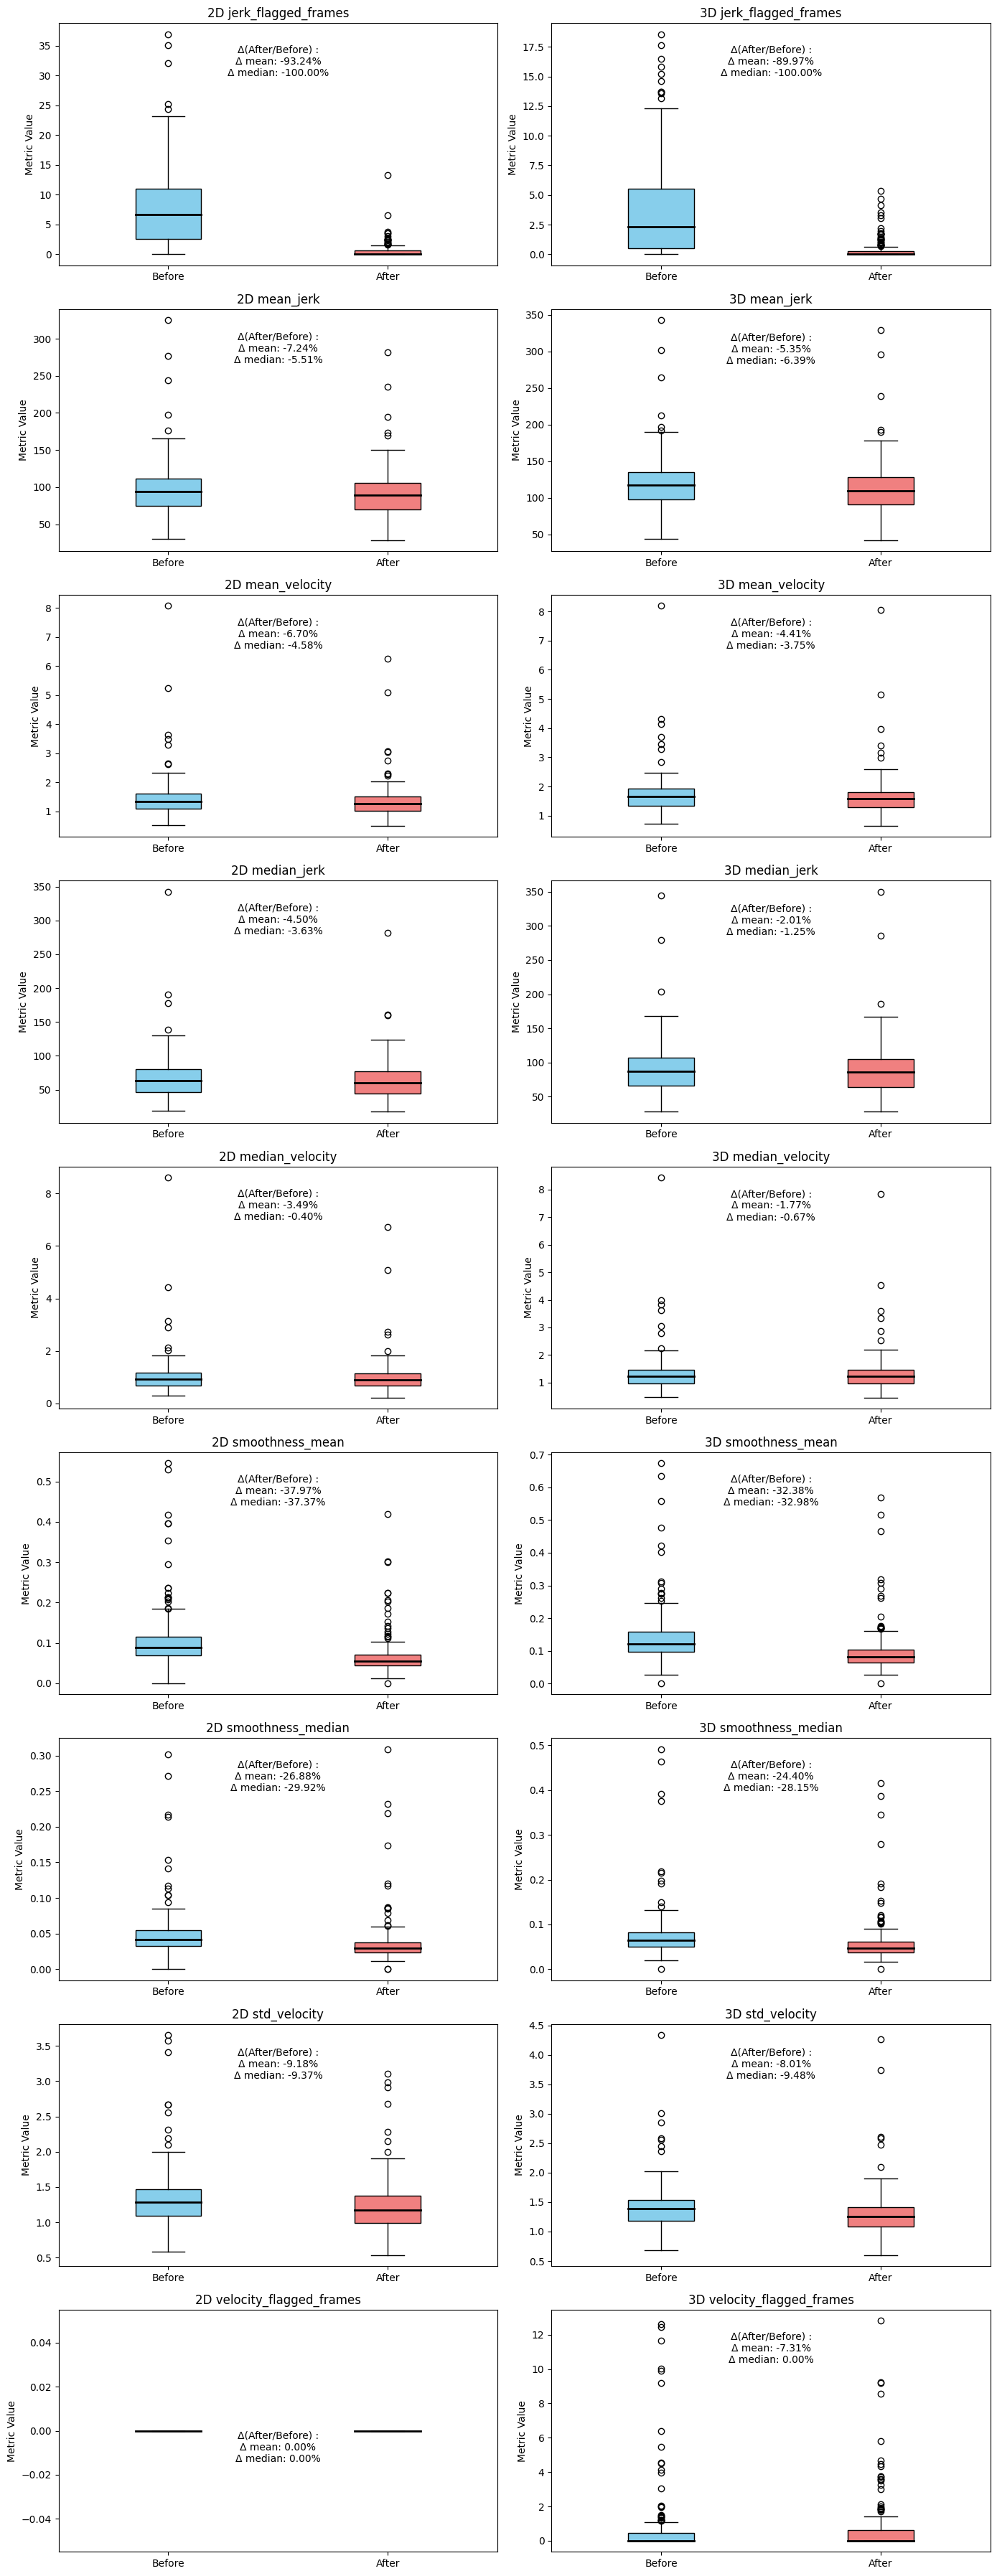

In [138]:
import pandas as pd
import matplotlib.pyplot as plt
import json
import os
import numpy as np

# Function to load JSON files from a directory
def load_json_files(directory):
    data = []
    for filename in os.listdir(directory):
        if filename.endswith('.json'):
            with open(os.path.join(directory, filename), 'r') as file:
                data.append(json.load(file))
    return data

# Function to combine metric values from all actions into one dataset and filter out None/NaN
def gather_all_metrics(metric_data, metric_name):
    before_values = []
    after_values = []
    for entry in metric_data:
        if metric_name in entry:
            # Extract values and filter out None and NaN
            before = [x for x in entry[metric_name]['before'] if x is not None and not pd.isna(x)]
            after = [x for x in entry[metric_name]['after'] if x is not None and not pd.isna(x)]
            before_values.extend(before)
            after_values.extend(after)
    return before_values, after_values

# Function to calculate mean and median percentage differences
def calculate_percentage_diff(before, after):
    mean_diff = ((np.mean(after) - np.mean(before)) / np.mean(before)) * 100 if np.mean(before) != 0 else 0
    median_diff = ((np.median(after) - np.median(before)) / np.median(before)) * 100 if np.median(before) != 0 else 0
    return mean_diff, median_diff

# Define paths for 2D and 3D metric directories
path_2d = 'kalman_metrics/2D/'
path_3d = 'kalman_metrics/3D/'

color_before = 'skyblue'
color_after = 'lightcoral'

# Load data from the 2D and 3D directories
metrics_2d = load_json_files(path_2d)
metrics_3d = load_json_files(path_3d)

# Get all unique metric keys from the data
all_keys = set()
for entry in metrics_2d + metrics_3d:
    all_keys.update(entry.keys())

# Plot combined box plots for both 2D and 3D data
fig, axes = plt.subplots(len(all_keys), 2, figsize=(14, len(all_keys) * 4))  # Adjust height based on the number of metrics

for i, metric in enumerate(sorted(all_keys)):
    # Gather all metric values for 2D and 3D
    before_2d, after_2d = gather_all_metrics(metrics_2d, metric)
    before_3d, after_3d = gather_all_metrics(metrics_3d, metric)
    
    if before_2d and after_2d:
        # Calculate mean and median percentage differences for 2D
        mean_diff_2d, median_diff_2d = calculate_percentage_diff(before_2d, after_2d)
        
        # Plot 2D metrics as separate box plots
        axes[i, 0].boxplot(before_2d, positions=[1], widths=0.3, patch_artist=True,
                           boxprops=dict(facecolor=color_before), medianprops=dict(color='black', linewidth=2))
        axes[i, 0].boxplot(after_2d, positions=[2], widths=0.3, patch_artist=True,
                           boxprops=dict(facecolor=color_after), medianprops=dict(color='black', linewidth=2))
        axes[i, 0].set_xticks([1, 2])
        axes[i, 0].set_xticklabels(['Before', 'After'])
        axes[i, 0].set_title(f'2D {metric}')
        axes[i, 0].set_ylabel('Metric Value')
        axes[i, 0].text(1.5, max(before_2d + after_2d) * 0.95, 
                        f'Δ(After/Before) :\nΔ mean: {mean_diff_2d:.2f}%\nΔ median: {median_diff_2d:.2f}%',
                        fontsize=10, verticalalignment='top', horizontalalignment='center',
                        bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))

    if before_3d and after_3d:
        # Calculate mean and median percentage differences for 3D
        mean_diff_3d, median_diff_3d = calculate_percentage_diff(before_3d, after_3d)
        
        # Plot 3D metrics as separate box plots
        axes[i, 1].boxplot(before_3d, positions=[1], widths=0.3, patch_artist=True,
                           boxprops=dict(facecolor=color_before), medianprops=dict(color='black', linewidth=2))
        axes[i, 1].boxplot(after_3d, positions=[2], widths=0.3, patch_artist=True,
                           boxprops=dict(facecolor=color_after), medianprops=dict(color='black', linewidth=2))
        axes[i, 1].set_xticks([1, 2])
        axes[i, 1].set_xticklabels(['Before', 'After'])
        axes[i, 1].set_title(f'3D {metric}')
        axes[i, 1].set_ylabel('Metric Value')
        axes[i, 1].text(1.5, max(before_3d + after_3d) * 0.95, 
                        f'Δ(After/Before) :\nΔ mean: {mean_diff_3d:.2f}%\nΔ median: {median_diff_3d:.2f}%',
                        fontsize=10, verticalalignment='top', horizontalalignment='center',
                        bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))

# Improve layout
plt.tight_layout()
plt.show()


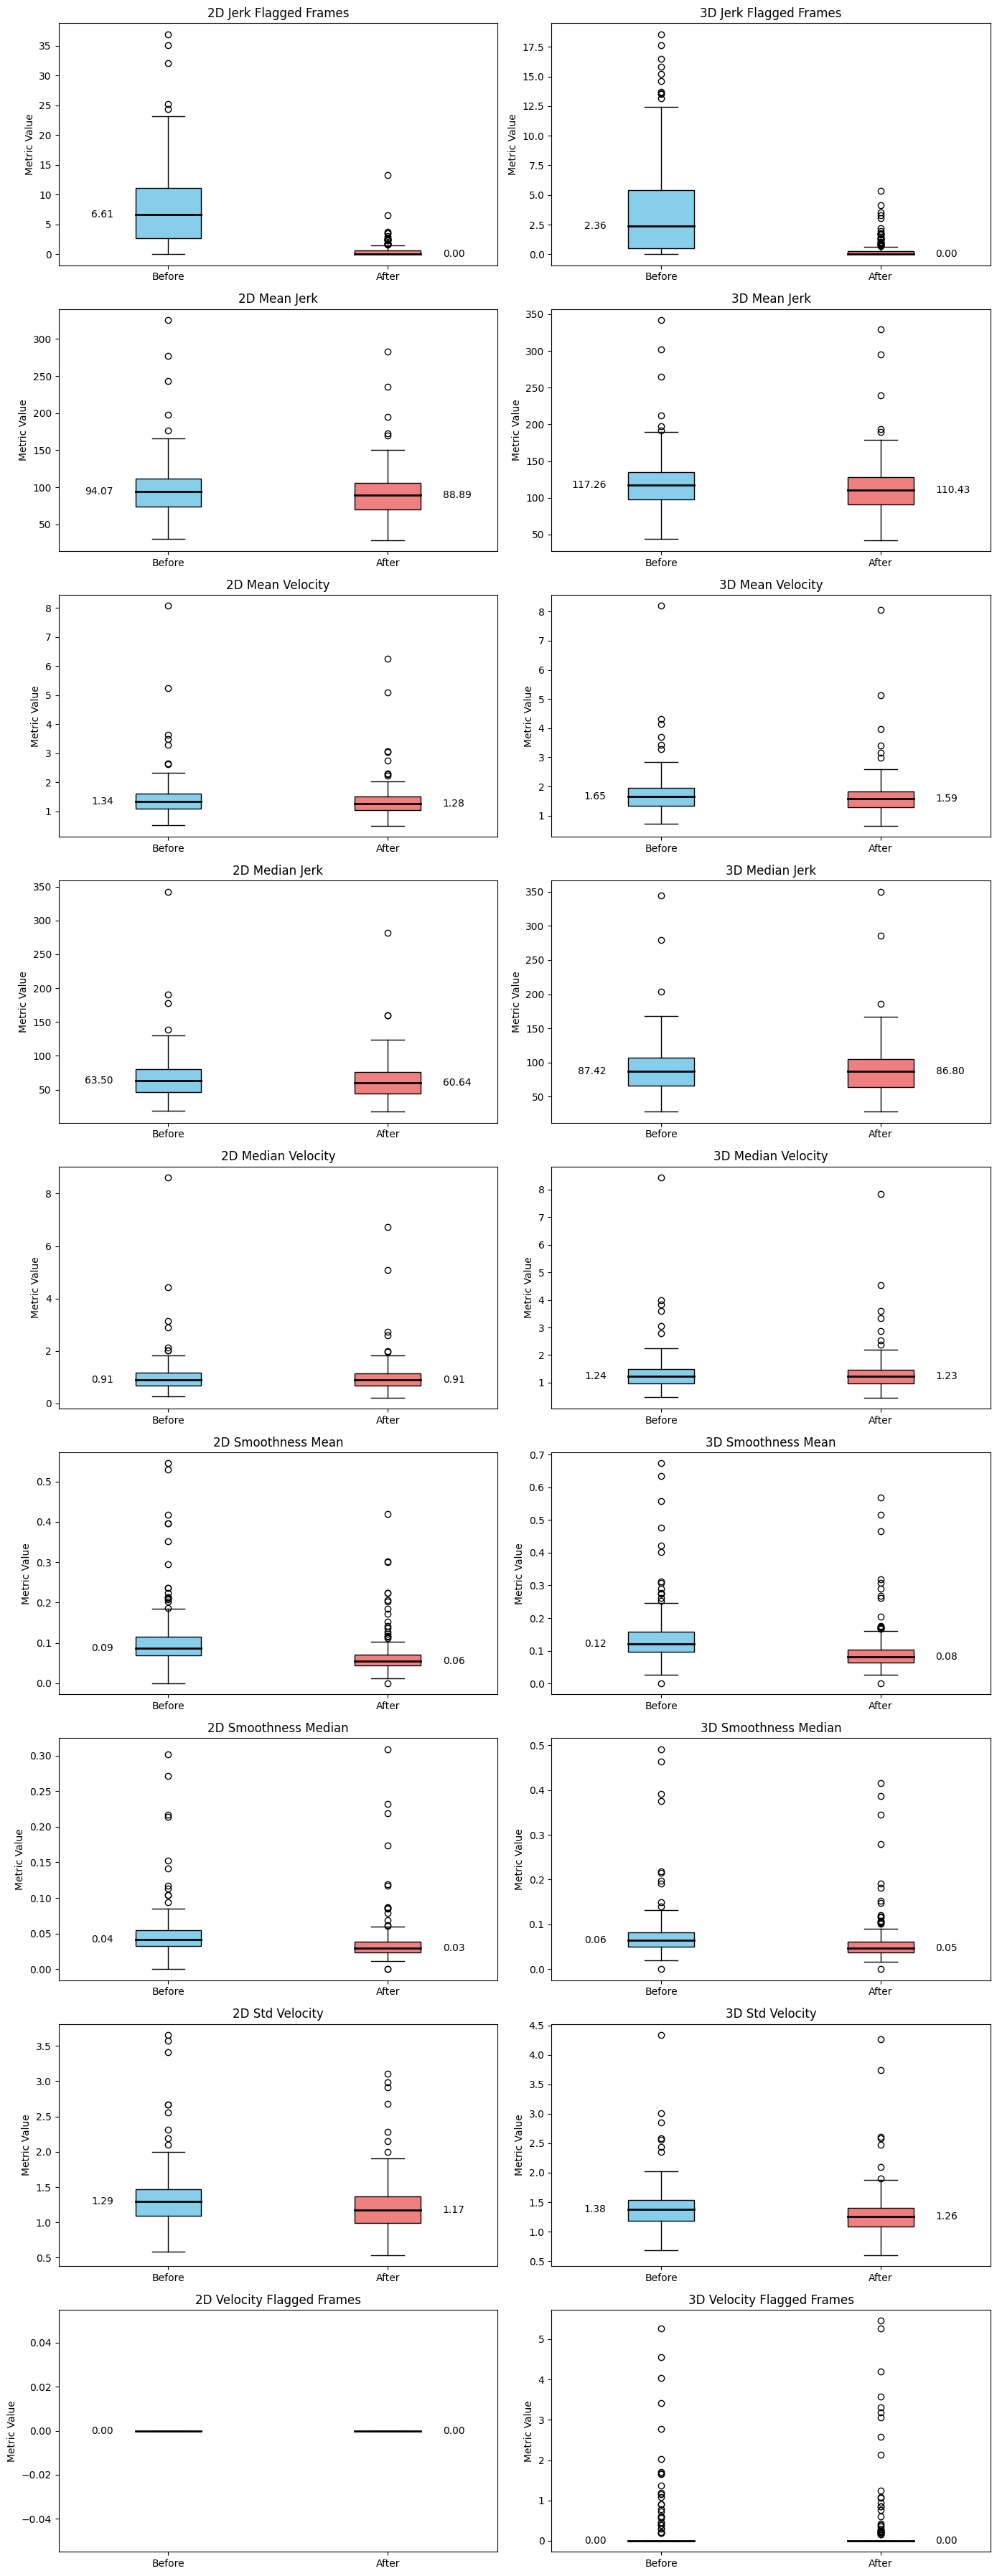

In [173]:
import pandas as pd
import matplotlib.pyplot as plt
import json
import os
import numpy as np

# Function to load JSON files from a directory
def load_json_files(directory):
    data = []
    for filename in os.listdir(directory):
        if filename.endswith('.json'):
            with open(os.path.join(directory, filename), 'r') as file:
                data.append(json.load(file))
    return data

# Function to combine metric values from all actions into one dataset and filter out None/NaN
def gather_all_metrics(metric_data, metric_name):
    before_values = []
    after_values = []
    for entry in metric_data:
        if metric_name in entry:
            # Extract values and filter out None and NaN
            before = [x for x in entry[metric_name]['before'] if x is not None and not pd.isna(x)]
            after = [x for x in entry[metric_name]['after'] if x is not None and not pd.isna(x)]
            before_values.extend(before)
            after_values.extend(after)
    return before_values, after_values

# Function to calculate mean and median percentage differences
def calculate_percentage_diff(before, after):
    mean_diff = ((np.mean(after) - np.mean(before)) / np.mean(before)) * 100 if np.mean(before) != 0 else 0
    median_diff = ((np.median(after) - np.median(before)) / np.median(before)) * 100 if np.median(before) != 0 else 0
    return mean_diff, median_diff

# Define paths for 2D and 3D metric directories
path_2d = 'kalman_metrics/2D/'
path_3d = 'kalman_metrics/3D/'

# Load data from the 2D and 3D directories
metrics_2d = load_json_files(path_2d)
metrics_3d = load_json_files(path_3d)

# Get all unique metric keys from the data
all_keys = set()
for entry in metrics_2d + metrics_3d:
    all_keys.update(entry.keys())

# Function to format metric names for better visualization
def format_metric_name(metric):
    return ' '.join(word.capitalize() for word in metric.split('_'))

# Define consistent colors for "before" and "after"
color_before = 'skyblue'
color_after = 'lightcoral'

# Plot combined box plots for both 2D and 3D data
fig, axes = plt.subplots(len(all_keys), 2, figsize=(14, len(all_keys) * 4))  # Adjust height based on the number of metrics

for i, metric in enumerate(sorted(all_keys)):
    # Gather all metric values for 2D and 3D
    before_2d, after_2d = gather_all_metrics(metrics_2d, metric)
    before_3d, after_3d = gather_all_metrics(metrics_3d, metric)
    
    formatted_metric_name = format_metric_name(metric)
    
    if before_2d and after_2d:
        # Calculate mean and median percentage differences for 2D
        mean_diff_2d, median_diff_2d = calculate_percentage_diff(before_2d, after_2d)
        median_before_2d = np.median(before_2d)
        median_after_2d = np.median(after_2d)
        
        # Plot 2D metrics as separate box plots with different colors
        box_2d_before = axes[i, 0].boxplot(before_2d, positions=[1], widths=0.3, patch_artist=True,
                                           boxprops=dict(facecolor=color_before), medianprops=dict(color='black', linewidth=2))
        box_2d_after = axes[i, 0].boxplot(after_2d, positions=[2], widths=0.3, patch_artist=True,
                                          boxprops=dict(facecolor=color_after), medianprops=dict(color='black', linewidth=2))
        axes[i, 0].set_xticks([1, 2])
        axes[i, 0].set_xticklabels(['Before', 'After'])
        axes[i, 0].set_title(f'2D {formatted_metric_name}')
        axes[i, 0].set_ylabel('Metric Value')

        # Annotate median values in black
        axes[i, 0].text(0.75, median_before_2d, f'{median_before_2d:.2f}', ha='right', va='center', fontsize=10, color='black')
        axes[i, 0].text(2.25, median_after_2d, f'{median_after_2d:.2f}', ha='left', va='center', fontsize=10, color='black')

    if before_3d and after_3d:
        # Calculate mean and median percentage differences for 3D
        mean_diff_3d, median_diff_3d = calculate_percentage_diff(before_3d, after_3d)
        median_before_3d = np.median(before_3d)
        median_after_3d = np.median(after_3d)
        
        # Plot 3D metrics as separate box plots with different colors
        box_3d_before = axes[i, 1].boxplot(before_3d, positions=[1], widths=0.3, patch_artist=True,
                                           boxprops=dict(facecolor=color_before), medianprops=dict(color='black', linewidth=2))
        box_3d_after = axes[i, 1].boxplot(after_3d, positions=[2], widths=0.3, patch_artist=True,
                                          boxprops=dict(facecolor=color_after), medianprops=dict(color='black', linewidth=2))
        axes[i, 1].set_xticks([1, 2])
        axes[i, 1].set_xticklabels(['Before', 'After'])
        axes[i, 1].set_title(f'3D {formatted_metric_name}')
        axes[i, 1].set_ylabel('Metric Value')

        # Annotate median values in black
        axes[i, 1].text(0.75, median_before_3d, f'{median_before_3d:.2f}', ha='right', va='center', fontsize=10, color='black')
        axes[i, 1].text(2.25, median_after_3d, f'{median_after_3d:.2f}', ha='left', va='center', fontsize=10, color='black')

# Improve layout
plt.tight_layout()
plt.show()


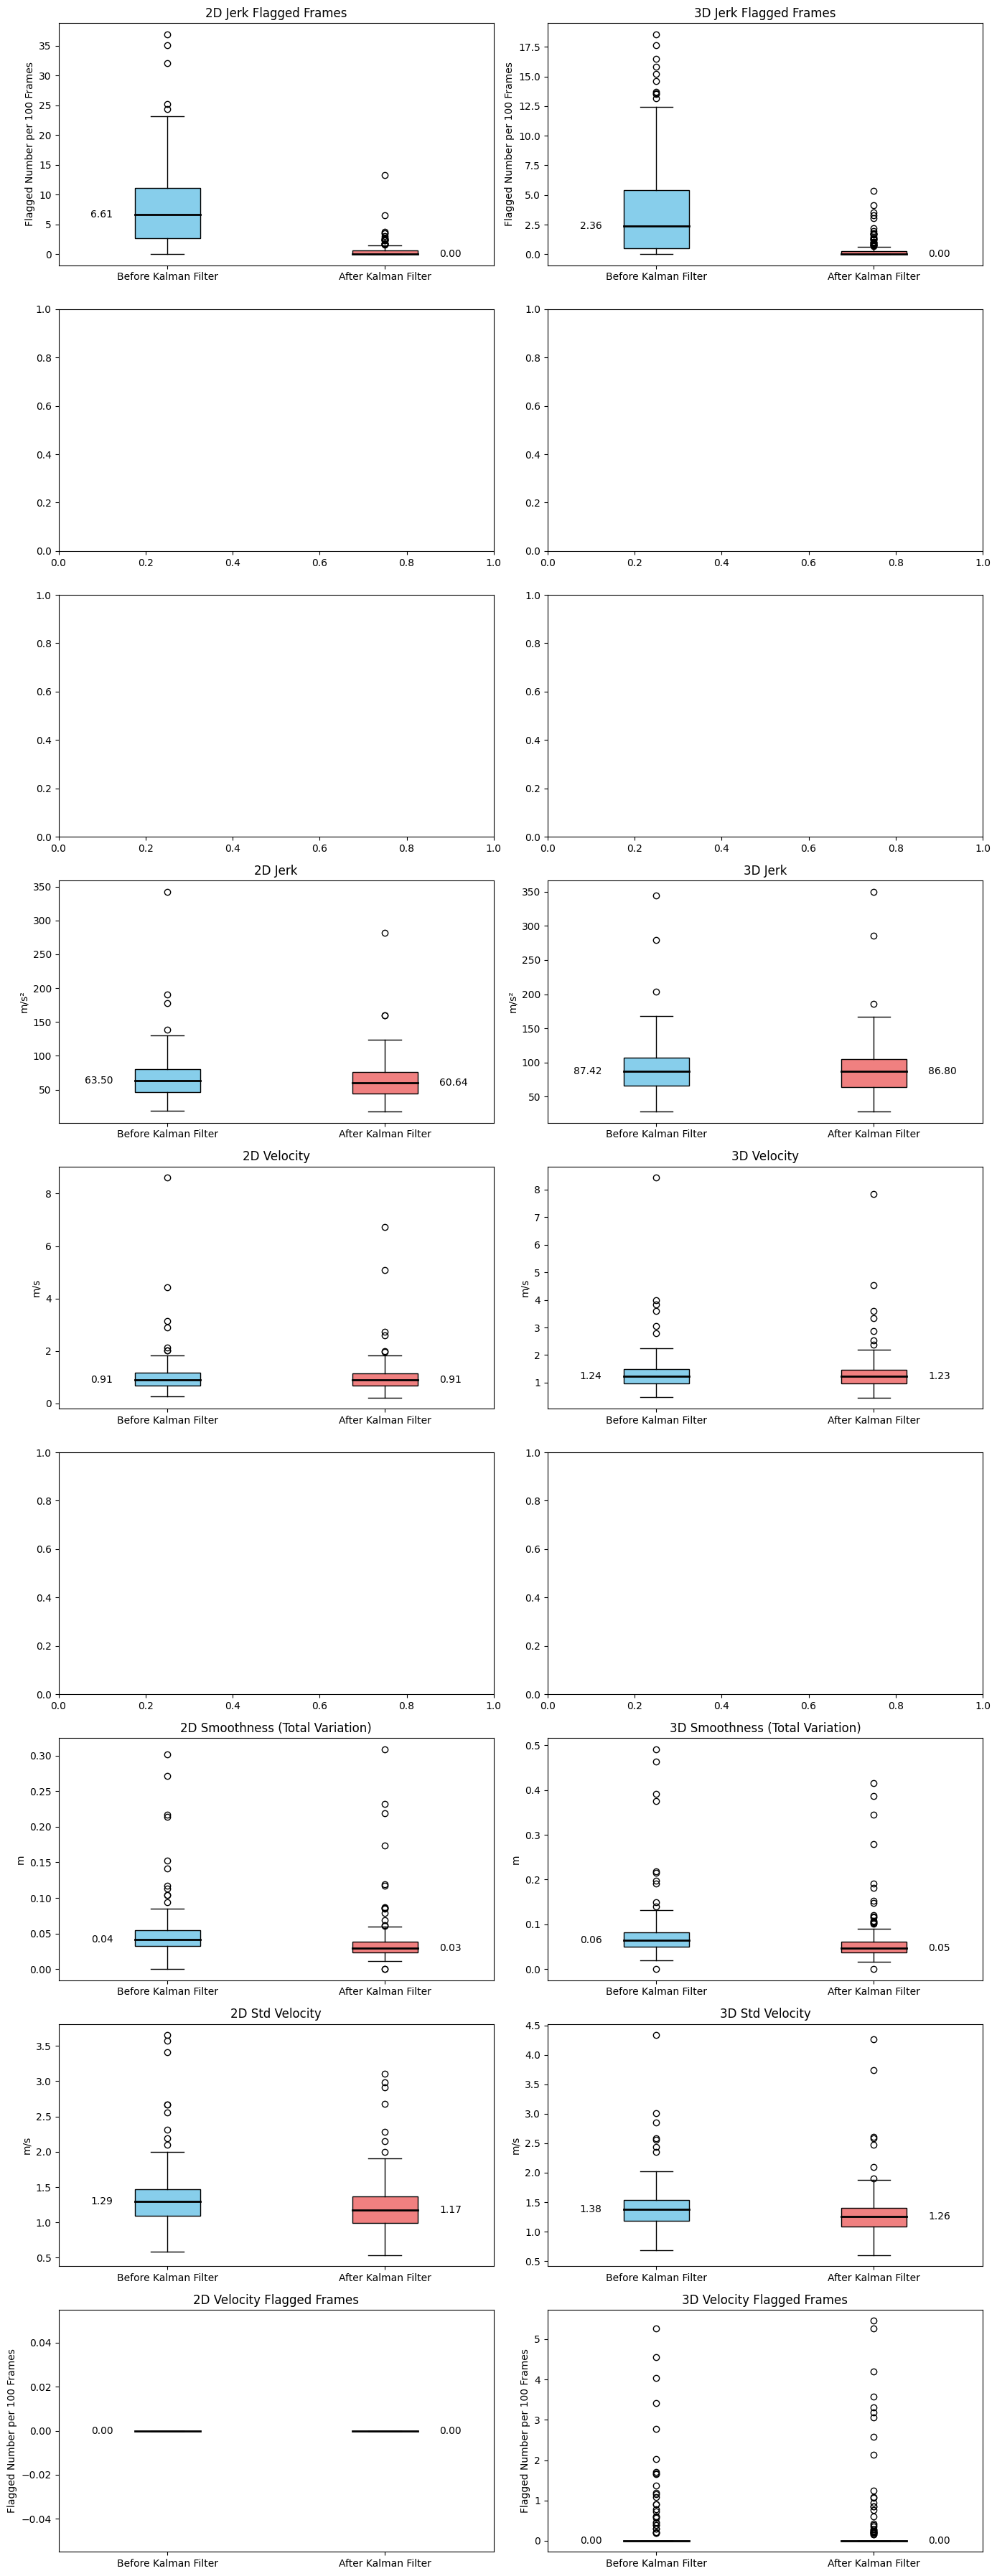

In [172]:
import pandas as pd
import matplotlib.pyplot as plt
import json
import os
import numpy as np

# Function to load JSON files from a directory
def load_json_files(directory):
    data = []
    for filename in os.listdir(directory):
        if filename.endswith('.json'):
            with open(os.path.join(directory, filename), 'r') as file:
                data.append(json.load(file))
    return data

# Function to combine metric values from all actions into one dataset and filter out None/NaN
def gather_all_metrics(metric_data, metric_name):
    before_values = []
    after_values = []
    for entry in metric_data:
        if metric_name in entry:
            # Extract values and filter out None and NaN
            before = [x for x in entry[metric_name]['before'] if x is not None and not pd.isna(x)]
            after = [x for x in entry[metric_name]['after'] if x is not None and not pd.isna(x)]
            before_values.extend(before)
            after_values.extend(after)
    return before_values, after_values

# Function to calculate mean and median percentage differences
def calculate_percentage_diff(before, after):
    mean_diff = ((np.mean(after) - np.mean(before)) / np.mean(before)) * 100 if np.mean(before) != 0 else 0
    median_diff = ((np.median(after) - np.median(before)) / np.median(before)) * 100 if np.median(before) != 0 else 0
    return mean_diff, median_diff

# Define paths for 2D and 3D metric directories
path_2d = 'kalman_metrics/2D/'
path_3d = 'kalman_metrics/3D/'

# Load data from the 2D and 3D directories
metrics_2d = load_json_files(path_2d)
metrics_3d = load_json_files(path_3d)

# Get all unique metric keys from the data
all_keys = set()
for entry in metrics_2d + metrics_3d:
    all_keys.update(entry.keys())

# Function to format metric names for better visualization
def format_metric_name(metric):
    return ' '.join(word.capitalize() for word in metric.split('_'))

# Function to get appropriate y-labels based on metric name
def get_y_label(metric):
    if 'flagged' in metric and ('velo' in metric or 'jerk' in metric):
        return 'Flagged Number per 100 Frames'
    elif 'velocity' in metric:
        return 'm/s'
    elif 'jerk' in metric:
        return 'm/s²'
    elif 'smoothness' in metric:
        return 'm'
    else:
        return 'Metric Value'

# Define consistent colors for "before" and "after"
color_before = 'skyblue'
color_after = 'lightcoral'

# Plot combined box plots for both 2D and 3D data
fig, axes = plt.subplots(len(all_keys), 2, figsize=(14, len(all_keys) * 4))  # Adjust height based on the number of metrics

for i, metric in enumerate(sorted(all_keys)):
    # Gather all metric values for 2D and 3D
    before_2d, after_2d = gather_all_metrics(metrics_2d, metric)
    before_3d, after_3d = gather_all_metrics(metrics_3d, metric)
    
    formatted_metric_name = format_metric_name(metric)
    if formatted_metric_name in ["Mean Jerk", "Mean Velocity", "Smoothness Mean"]:
        continue
    if formatted_metric_name == "Smoothness Median":
        formatted_metric_name = "Smoothness (Total Variation)"
    if formatted_metric_name == "Median Jerk":
        formatted_metric_name = "Jerk"
    if formatted_metric_name == "Median Velocity":
        formatted_metric_name = "Velocity"


    y_label = get_y_label(metric)
    
    if before_2d and after_2d:
        # Calculate mean and median percentage differences for 2D
        mean_diff_2d, median_diff_2d = calculate_percentage_diff(before_2d, after_2d)
        median_before_2d = np.median(before_2d)
        median_after_2d = np.median(after_2d)
        
        # Plot 2D metrics as separate box plots with different colors
        box_2d_before = axes[i, 0].boxplot(before_2d, positions=[1], widths=0.3, patch_artist=True,
                                           boxprops=dict(facecolor=color_before), medianprops=dict(color='black', linewidth=2))
        box_2d_after = axes[i, 0].boxplot(after_2d, positions=[2], widths=0.3, patch_artist=True,
                                          boxprops=dict(facecolor=color_after), medianprops=dict(color='black', linewidth=2))
        axes[i, 0].set_xticks([1, 2])
        axes[i, 0].set_xticklabels(['Before Kalman Filter', 'After Kalman Filter'])
        axes[i, 0].set_title(f'2D {formatted_metric_name}')
        axes[i, 0].set_ylabel(y_label)

        # Annotate median values in black
        axes[i, 0].text(0.75, median_before_2d, f'{median_before_2d:.2f}', ha='right', va='center', fontsize=10, color='black')
        axes[i, 0].text(2.25, median_after_2d, f'{median_after_2d:.2f}', ha='left', va='center', fontsize=10, color='black')

    if before_3d and after_3d:
        # Calculate mean and median percentage differences for 3D
        mean_diff_3d, median_diff_3d = calculate_percentage_diff(before_3d, after_3d)
        median_before_3d = np.median(before_3d)
        median_after_3d = np.median(after_3d)
        
        # Plot 3D metrics as separate box plots with different colors
        box_3d_before = axes[i, 1].boxplot(before_3d, positions=[1], widths=0.3, patch_artist=True,
                                           boxprops=dict(facecolor=color_before), medianprops=dict(color='black', linewidth=2))
        box_3d_after = axes[i, 1].boxplot(after_3d, positions=[2], widths=0.3, patch_artist=True,
                                          boxprops=dict(facecolor=color_after), medianprops=dict(color='black', linewidth=2))
        axes[i, 1].set_xticks([1, 2])
        axes[i, 1].set_xticklabels(['Before Kalman Filter', 'After Kalman Filter'])
        axes[i, 1].set_title(f'3D {formatted_metric_name}')
        axes[i, 1].set_ylabel(y_label)

        # Annotate median values in black
        axes[i, 1].text(0.75, median_before_3d, f'{median_before_3d:.2f}', ha='right', va='center', fontsize=10, color='black')
        axes[i, 1].text(2.25, median_after_3d, f'{median_after_3d:.2f}', ha='left', va='center', fontsize=10, color='black')

# Improve layout
plt.tight_layout()
plt.show()


In [167]:
for i, metric in enumerate(sorted(all_keys)):
    # Gather all metric values for 2D and 3D
    before_2d, after_2d = gather_all_metrics(metrics_2d, metric)
    before_3d, after_3d = gather_all_metrics(metrics_3d, metric)


    print(f'Metric: {metric}')
 
    print(f'3D Median Before Kalman: {np.median(before_3d)}')
    print(f'3D Median After Kalman: {np.median(after_3d)}')
    print(f'3D Percentage Median Difference: {((np.median(after_3d) - np.median(before_3d)) / np.median(before_3d)) * 100:.2f}%')


    print(f'3D Mean Before Kalman: {np.mean(before_3d)}')
    print(f'3D Mean After Kalman: {np.mean(after_3d)}')
    print(f'3D Percentage Mean Difference: {((np.mean(after_3d) - np.mean(before_3d)) / np.mean(before_3d)) * 100:.2f}%')


    print('---')



Metric: jerk_flagged_frames
3D Median Before Kalman: 2.3415191319246142
3D Median After Kalman: 0.0
3D Percentage Median Difference: -100.00%
3D Mean Before Kalman: 3.7113571315661162
3D Mean After Kalman: 0.37232624650706614
3D Percentage Mean Difference: -89.97%
---
Metric: mean_jerk
3D Median Before Kalman: 117.25866619787614
3D Median After Kalman: 109.76333587755137
3D Percentage Median Difference: -6.39%
3D Mean Before Kalman: 118.80253184161
3D Mean After Kalman: 112.45095612573392
3D Percentage Mean Difference: -5.35%
---
Metric: mean_velocity
3D Median Before Kalman: 1.6477741737313523
3D Median After Kalman: 1.5860288997266057
3D Percentage Median Difference: -3.75%
3D Mean Before Kalman: 1.7118599309663627
3D Mean After Kalman: 1.6362930415715105
3D Percentage Mean Difference: -4.41%
---
Metric: median_jerk
3D Median Before Kalman: 87.41634369289193
3D Median After Kalman: 86.3247400294182
3D Percentage Median Difference: -1.25%
3D Mean Before Kalman: 91.92264945804816
3D Me

c:\Users\strom\anaconda3\envs\cuda116\lib\site-packages\ipykernel_launcher.py:11: RuntimeWarning: invalid value encountered in double_scalars
  # This is added back by InteractiveShellApp.init_path()


In [168]:
for i, metric in enumerate(sorted(all_keys)):
    # Gather all metric values for 2D and 3D
    before_2d, after_2d = gather_all_metrics(metrics_2d, metric)
    before_3d, after_3d = gather_all_metrics(metrics_3d, metric)


    print(f'Metric: {metric}')
    print(f'2D Median Before Kalman: {np.median(before_2d)}')
    print(f'2D Median After Kalman: {np.median(after_2d)}')
    print(f'2D Percentage Median Difference: {((np.median(after_2d) - np.median(before_2d)) / np.median(before_2d)) * 100:.2f}%')


    print(f'2D Mean Before Kalman: {np.mean(before_2d)}')
    print(f'2D Mean After Kalman: {np.mean(after_2d)}')
    print(f'2D Percentage Mean Difference: {((np.mean(after_2d) - np.mean(before_2d)) / np.mean(before_2d)) * 100:.2f}%')



    print('---')

Metric: jerk_flagged_frames
2D Median Before Kalman: 6.706683402164817
2D Median After Kalman: 0.0
2D Percentage Median Difference: -100.00%
2D Mean Before Kalman: 8.19179064453383
2D Mean After Kalman: 0.5540287917465622
2D Percentage Mean Difference: -93.24%
---
Metric: mean_jerk
2D Median Before Kalman: 94.06844619028715
2D Median After Kalman: 88.88919228028972
2D Percentage Median Difference: -5.51%
2D Mean Before Kalman: 96.26755792332975
2D Mean After Kalman: 89.3020090532673
2D Percentage Mean Difference: -7.24%
---
Metric: mean_velocity
2D Median Before Kalman: 1.3370586563436184
2D Median After Kalman: 1.27581139415875
2D Percentage Median Difference: -4.58%
2D Mean Before Kalman: 1.42969976609567
2D Mean After Kalman: 1.3339262234827858
2D Percentage Mean Difference: -6.70%
---
Metric: median_jerk
2D Median Before Kalman: 62.92022640045169
2D Median After Kalman: 60.63523026323986
2D Percentage Median Difference: -3.63%
2D Mean Before Kalman: 66.87175237405016
2D Mean After 

c:\Users\strom\anaconda3\envs\cuda116\lib\site-packages\ipykernel_launcher.py:10: RuntimeWarning: invalid value encountered in double_scalars
  # Remove the CWD from sys.path while we load stuff.
c:\Users\strom\anaconda3\envs\cuda116\lib\site-packages\ipykernel_launcher.py:15: RuntimeWarning: invalid value encountered in double_scalars
  from ipykernel import kernelapp as app


In [5]:
import numpy as np
from scipy.stats import spearmanr
from sklearn.metrics import ndcg_score

# Define the actual data for evaluation
# Input 1 or 0 manually here for each metric type in the 1-choice task
results_1_choice = {
    'cosine': np.array([1,0,0,1,1,0,0,1,0]),  # Example data for 12 samples
    'euclidean': np.array([0,0,1,0,1,0,0,1,0]),
    'combined': np.array([0,0,0,0,0,1,0,0,1]),
}



# Input 1 or 0 manually here for each feature type in the 1-choice task
results_features = {
    'poses': np.array([0,0,1,0,0,0,1,0,0,0]),  # Example data for 10 samples
    'poses_lin_vel': np.array([0,0,0,1,0,0,0,0,1,0]),
    'angles_vel_acc': np.array([1,0,0,0,0,0,0,0,0,0]),
    'all_features': np.array([0,1,0,0,1,1,0,1,0,1]),
}

# Define rankings for each model with 5 different rankings as examples
# Replace each permutation with the actual ranking data
ranking_data = {
    'LSTM': [
        np.array([0,2,1,3]),  # Replace with actual ranking data
        np.array([0,1,2,3]),
        np.array([1,3,0,2]),
        np.array([2,0,1,3]),
        np.array([1,3,0,2])
    ],
    'LSTM_FC': [
        np.array([1,0,3,2]),
        np.array([3,0,2,1]),
        np.array([2,1,0,3]),
        np.array([2,1,0,3]),
        np.array([3,2,1,0])
    ],
    'naive': [
        np.array([0,3,1,2]),
        np.array([0,3,2,1]),
        np.array([2,0,1,3]),
        np.array([3,2,1,0]),
        np.array([1,0,3,2])
    ],
}

ground_truth_ranking = np.array([0, 1, 2, 3])

# Function to calculate agreement score and accuracy
def calculate_agreement_accuracy(results):
    agreement_score = np.mean(results)
    accuracy = np.sum(results) / len(results)
    return agreement_score, accuracy

# Evaluate metrics for 1-choice task
for metric, results in results_1_choice.items():
    agreement, accuracy = calculate_agreement_accuracy(results)
    print(f"{metric.capitalize()} -  Accuracy: {accuracy:.2f}")

# Evaluate features for 1-choice task
for feature, results in results_features.items():
    agreement, accuracy = calculate_agreement_accuracy(results)
    print(f"{feature.replace('_', ' ').capitalize()} -  Accuracy: {accuracy:.2f}")

# Evaluate rankings using Spearman's coefficient and NDCG
for model, rankings in ranking_data.items():
    spearman_coeffs = [spearmanr(ground_truth_ranking, ranking)[0] for ranking in rankings]
    avg_spearman = np.mean(spearman_coeffs)
    
    ndcg_scores = [ndcg_score([ground_truth_ranking], [ranking], k=len(ground_truth_ranking)) for ranking in rankings]
    avg_ndcg = np.mean(ndcg_scores)
    
    print(f"\nModel: {model}")
    print(f"Average Spearman's Coefficient: {avg_spearman:.2f}")
    print(f"Average NDCG Score: {avg_ndcg:.2f}")

Cosine -  Accuracy: 0.44
Euclidean -  Accuracy: 0.33
Combined -  Accuracy: 0.22
Poses -  Accuracy: 0.20
Poses lin vel -  Accuracy: 0.20
Angles vel acc -  Accuracy: 0.10
All features -  Accuracy: 0.50

Model: LSTM
Average Spearman's Coefficient: 0.44
Average NDCG Score: 0.90

Model: LSTM_FC
Average Spearman's Coefficient: -0.08
Average NDCG Score: 0.80

Model: naive
Average Spearman's Coefficient: 0.12
Average NDCG Score: 0.81


In [6]:
import numpy as np
from scipy.stats import spearmanr
from sklearn.metrics import ndcg_score

# Define the actual data for evaluation
# Input 1 or 0 manually here for each metric type in the 1-choice task
results_1_choice = {
    'cosine': np.array([0,0,1,1,1,0,1,1,1]),  # Example data for 12 samples
    'euclidean': np.array([0,0,1,1,0,0,0,0,0]),
    'combined': np.array([0,0,0,0,0,0,0,1,0]),
}

# Input 1 or 0 manually here for each feature type in the 1-choice task
results_features = {
    'poses': np.array([0,0,0,1,0,0,0,0,0,0]),  # Example data for 10 samples
    'poses_lin_vel': np.array([0,0,0,0,1,0,0,0,0,1]),
    'angles_vel_acc': np.array([0,0,1,0,0,1,1,0,0,0]),
    'all_features': np.array([1,1,0,0,0,0,0,1,1,]),
}

# Define rankings for each model with 5 different rankings as examples
# Replace each permutation with the actual ranking data
ranking_data = {
    'LSTM': [
        np.array([0,2,1,3]),  # Replace with actual ranking data
        np.array([0,1,2,3]),
        np.array([0,1,3,2]),
        np.array([2,0,1,3]),
        np.array([1,0,3,2])
    ],
    'LSTM_FC': [
        np.array([0,2,1,3]),
        np.array([1,2,3,0]),
        np.array([2,1,3,0]),
        np.array([1,0,3,2]),
        np.array([1,0,3,2])
    ],
    'naive': [
        np.array([1,3,0,2]),
        np.array([1,2,3,0]),
        np.array([3,1,2,0]),
        np.array([3,1,2,0]),
        np.array([2,1,0,3])
    ],
}

ground_truth_ranking = np.array([0, 1, 2, 3])

# Function to calculate agreement score and accuracy
def calculate_agreement_accuracy(results):
    agreement_score = np.mean(results)
    accuracy = np.sum(results) / len(results)
    return agreement_score, accuracy

# Evaluate metrics for 1-choice task
for metric, results in results_1_choice.items():
    agreement, accuracy = calculate_agreement_accuracy(results)
    print(f"{metric.capitalize()} -  Accuracy: {accuracy:.2f}")

# Evaluate features for 1-choice task
for feature, results in results_features.items():
    agreement, accuracy = calculate_agreement_accuracy(results)
    print(f"{feature.replace('_', ' ').capitalize()} - Accuracy: {accuracy:.2f}")

# Evaluate rankings using Spearman's coefficient and NDCG
for model, rankings in ranking_data.items():
    spearman_coeffs = [spearmanr(ground_truth_ranking, ranking)[0] for ranking in rankings]
    avg_spearman = np.mean(spearman_coeffs)
    
    ndcg_scores = [ndcg_score([ground_truth_ranking], [ranking], k=len(ground_truth_ranking)) for ranking in rankings]
    avg_ndcg = np.mean(ndcg_scores)
    
    print(f"\nModel: {model}")
    print(f"Average Spearman's Coefficient: {avg_spearman:.2f}")
    print(f"Average NDCG Score: {avg_ndcg:.2f}")

Cosine -  Accuracy: 0.67
Euclidean -  Accuracy: 0.22
Combined -  Accuracy: 0.11
Poses - Accuracy: 0.10
Poses lin vel - Accuracy: 0.20
Angles vel acc - Accuracy: 0.30
All features - Accuracy: 0.44

Model: LSTM
Average Spearman's Coefficient: 0.72
Average NDCG Score: 0.95

Model: LSTM_FC
Average Spearman's Coefficient: 0.28
Average NDCG Score: 0.88

Model: naive
Average Spearman's Coefficient: -0.32
Average NDCG Score: 0.76


In [189]:
results_1_choice_1 = {
    'cosine': np.array([1,0,1,1,0,0,1,1,0,0,1,0]),  # Example data for 12 samples
    'euclidean': np.array([0,0,1,0,1,0,0,0,0,0,0,0]),
    'combined': np.array([0,0,0,0,0,0,0,0,0,0,0,1]),
}

results_1_choice_2 = {
    'cosine': np.array([1,0,0,1,1,0,0,1,0,0,1,0]),  # Example data for 12 samples
    'euclidean': np.array([0,0,1,0,1,0,0,1,0,0,0,0]),
    'combined': np.array([0,0,0,0,0,0,0,0,0,0,0,1]),
}

# Input 1 or 0 manually here for each feature type in the 1-choice task
results_features_1 = {
    'poses': np.array([0,0,1,0,0,0,0,0,0,0]),  # Example data for 10 samples
    'poses_lin_vel': np.array([0,0,0,0,1,0,0,0,1,0]),
    'angles_vel_acc': np.array([0,0,0,1,0,1,1,0,0,0]),
    'all_features': np.array([1,1,0,0,0,0,0,1,0,1]),
}


# Input 1 or 0 manually here for each feature type in the 1-choice task
results_features_2 = {
    'poses': np.array([0,0,1,0,0,0,1,0,0,0]),  # Example data for 10 samples
    'poses_lin_vel': np.array([0,0,0,1,0,0,0,0,1,0]),
    'angles_vel_acc': np.array([1,0,0,0,0,0,0,0,0,0]),
    'all_features': np.array([0,1,0,0,1,1,0,1,0,1]),
}

In [190]:
# Function to compute agreement score
def calculate_agreement_score(results_1, results_2):
    scores = {}
    for key in results_1:
        scores[key] = np.sum(results_1[key] == results_2[key]) / len(results_1[key]) * 100
    return scores

# Calculate agreement for similarity metrics and features
agreement_similarity_metrics = calculate_agreement_score(results_1_choice_1, results_1_choice_2)
agreement_features = calculate_agreement_score(results_features_1, results_features_2)

# Combine results
agreement_scores = {
    'similarity_metrics': agreement_similarity_metrics,
    'features': agreement_features
}

print("Agreement Scores:", agreement_scores)

Agreement Scores: {'similarity_metrics': {'cosine': 75.0, 'euclidean': 91.66666666666666, 'combined': 100.0}, 'features': {'poses': 90.0, 'poses_lin_vel': 80.0, 'angles_vel_acc': 60.0, 'all_features': 70.0}}
